# V1 MLP Architecture Sweep — Comprehensive Characterisation

**Purpose**: Full analysis of all 17 MLP architectures trained in the V1 sweep.  
**Reference**: `v1_data_generation_and_training_protocol.pdf`, `bfield_characterisation.pdf`  
**Author**: G. Scriven  

This notebook:
1. Loads all completed model checkpoints and evaluates on the test split
2. Analyses convergence properties (training curves from logs)
3. Benchmarks against RK4 ground truth across momentum bins and B-field regions
4. Correlates errors with initial state variables (x, y, tx, ty, q/p, dz)
5. Examines x vs y deflection asymmetry (driven by By dominance)
6. Exports models to C binary format for QMTest integration

**Re-runnability**: Models still training will be skipped and flagged.

In [1]:
import sys
import json
import struct
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

# Project paths
V1_ROOT = Path('/data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1')
MODELS_DIR = V1_ROOT / 'models'
CHECKPOINTS_DIR = MODELS_DIR / 'checkpoints'
DATA_PATH = V1_ROOT / 'data_generation' / 'datasets' / 'train_50M.npz'
LOGS_DIR = MODELS_DIR / 'condor' / 'logs'
ANALYSIS_DIR = V1_ROOT / 'analysis'
ANALYSIS_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(MODELS_DIR))
sys.path.insert(0, str(V1_ROOT / 'utils'))
from architectures import create_model, MLP

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Checkpoints dir: {CHECKPOINTS_DIR}')

Device: cpu
Checkpoints dir: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/models/checkpoints


## 1. Discover Models and Check Completion Status

In [2]:
import re

def parse_training_log(log_path):
    """Parse Condor training log to extract epoch-by-epoch metrics."""
    epochs = []
    if not log_path.exists():
        return None
    text = log_path.read_text()
    
    for m in re.finditer(
        r'Epoch\s+(\d+)/(\d+):\s+train_loss=([\d.]+),\s+val_loss=([\d.]+),\s+val_pos=([\d.]+)mm,\s+lr=([\d.e+-]+)',
        text
    ):
        epochs.append({
            'epoch': int(m.group(1)),
            'max_epochs': int(m.group(2)),
            'train_loss': float(m.group(3)),
            'val_loss': float(m.group(4)),
            'val_pos_mm': float(m.group(5)),
            'lr': float(m.group(6)),
        })
    
    # Check completion
    completed = 'Training complete' in text or 'Early stopping' in text
    best_match = re.search(r'Best val loss: ([\d.]+)', text)
    best_epoch_match = re.search(r'Best epoch: (\d+)', text)
    
    return {
        'epochs': epochs,
        'completed': completed,
        'best_val_loss': float(best_match.group(1)) if best_match else None,
        'best_epoch': int(best_epoch_match.group(1)) if best_epoch_match else None,
        'n_epochs_trained': len(epochs),
    }


# Discover all models
all_model_names = sorted([
    d.name for d in CHECKPOINTS_DIR.iterdir()
    if d.is_dir() and (d / 'best_model.pt').exists()
])

model_status = OrderedDict()
for name in all_model_names:
    log_path = LOGS_DIR / f'{name}.out'
    parsed = parse_training_log(log_path)
    ckpt_dir = CHECKPOINTS_DIR / name
    
    # Load config
    config_path = ckpt_dir / 'config.json'
    config = json.loads(config_path.read_text()) if config_path.exists() else {}
    
    model_status[name] = {
        'hidden_dims': config.get('hidden_dims', []),
        'completed': parsed['completed'] if parsed else False,
        'best_val_loss': parsed['best_val_loss'] if parsed else None,
        'best_epoch': parsed['best_epoch'] if parsed else None,
        'n_epochs': parsed['n_epochs_trained'] if parsed else 0,
        'training_log': parsed,
    }

# Summary table
print(f"{'Model':<22} {'Dims':<22} {'Status':<12} {'Best Loss':>10} {'Best Epoch':>10} {'Epochs':>8}")
print('-' * 90)
for name, info in model_status.items():
    dims_str = str(info['hidden_dims'])
    status = 'DONE' if info['completed'] else 'RUNNING'
    loss = f"{info['best_val_loss']:.4f}" if info['best_val_loss'] is not None else '-'
    epoch = str(info['best_epoch']) if info['best_epoch'] is not None else '-'
    print(f"{name:<22} {dims_str:<22} {status:<12} {loss:>10} {epoch:>10} {info['n_epochs']:>8}")

completed_models = [n for n, s in model_status.items() if s['completed']]
running_models = [n for n, s in model_status.items() if not s['completed']]
print(f"\nCompleted: {len(completed_models)}, Still running: {len(running_models)}")
if running_models:
    print(f"Running: {', '.join(running_models)}")

Model                  Dims                   Status        Best Loss Best Epoch   Epochs
------------------------------------------------------------------------------------------
mlp_1024_512_256       [1024, 512, 256]       DONE             2.8043         22       52
mlp_128_64             [128, 64]              DONE             0.6833         99      129
mlp_256_128            [256, 128]             DONE             0.5857         50       80
mlp_256_256_128        [256, 256, 128]        DONE             1.4592         50       80
mlp_2x1024             [1024, 1024]           DONE             2.1050         61       91
mlp_2x128              [128, 128]             DONE             1.0096         53       83
mlp_2x256              [256, 256]             DONE             0.7891        131      161
mlp_2x512              [512, 512]             DONE             2.6045         38       68
mlp_2x64               [64, 64]               DONE             0.5713         84      114
mlp_3x128

## 2. Training Convergence Analysis

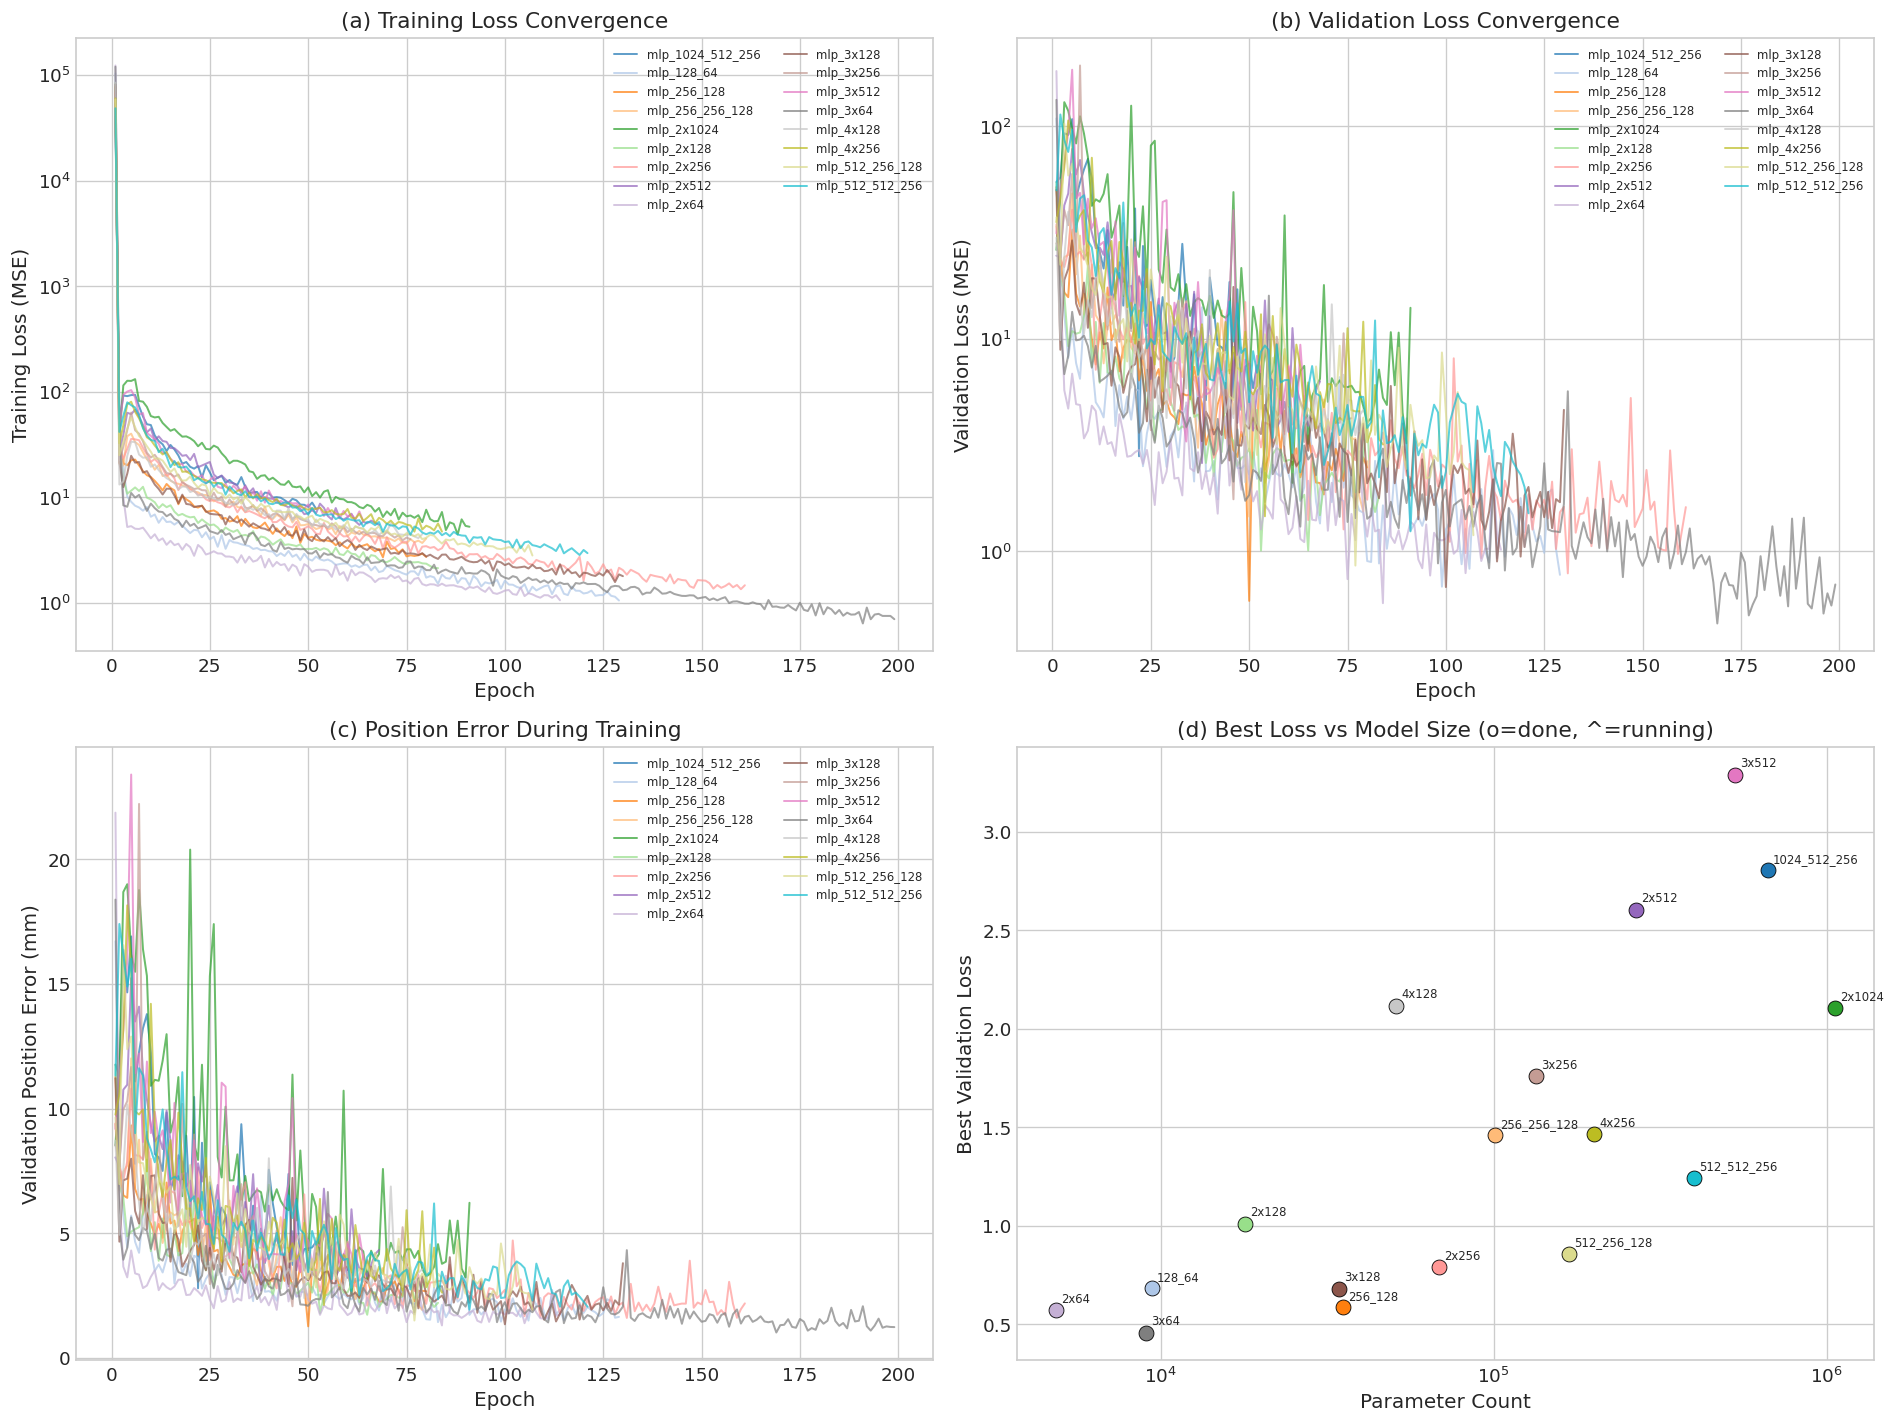

Saved to /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/convergence_analysis.png


In [3]:
def count_params(hidden_dims):
    """Count MLP parameters: input=6, output=4."""
    n = 0
    prev = 6
    for h in hidden_dims:
        n += prev * h + h  # weight + bias
        prev = h
    n += prev * 4 + 4  # output layer
    return n

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color map by model family
cmap = plt.cm.tab20
colors = {name: cmap(i / len(all_model_names)) for i, name in enumerate(all_model_names)}

# (a) Training loss curves
ax = axes[0, 0]
for name, info in model_status.items():
    log = info['training_log']
    if log and log['epochs']:
        ep = [e['epoch'] for e in log['epochs']]
        tl = [e['train_loss'] for e in log['epochs']]
        ax.plot(ep, tl, alpha=0.7, label=name, color=colors[name], linewidth=1.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (MSE)')
ax.set_title('(a) Training Loss Convergence')
ax.set_yscale('log')
ax.legend(fontsize=7, ncol=2, loc='upper right')

# (b) Validation loss curves
ax = axes[0, 1]
for name, info in model_status.items():
    log = info['training_log']
    if log and log['epochs']:
        ep = [e['epoch'] for e in log['epochs']]
        vl = [e['val_loss'] for e in log['epochs']]
        ax.plot(ep, vl, alpha=0.7, label=name, color=colors[name], linewidth=1.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('(b) Validation Loss Convergence')
ax.set_yscale('log')
ax.legend(fontsize=7, ncol=2, loc='upper right')

# (c) Validation position error
ax = axes[1, 0]
for name, info in model_status.items():
    log = info['training_log']
    if log and log['epochs']:
        ep = [e['epoch'] for e in log['epochs']]
        vp = [e['val_pos_mm'] for e in log['epochs']]
        ax.plot(ep, vp, alpha=0.7, label=name, color=colors[name], linewidth=1.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Position Error (mm)')
ax.set_title('(c) Position Error During Training')
ax.legend(fontsize=7, ncol=2, loc='upper right')

# (d) Best val loss vs parameter count
ax = axes[1, 1]
for name, info in model_status.items():
    if info['best_val_loss'] is not None:
        n_params = count_params(info['hidden_dims'])
        marker = 'o' if info['completed'] else '^'
        ax.scatter(n_params, info['best_val_loss'], color=colors[name],
                   s=80, marker=marker, edgecolors='black', linewidth=0.5, zorder=5)
        ax.annotate(name.replace('mlp_', ''), (n_params, info['best_val_loss']),
                    fontsize=7, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points')
ax.set_xlabel('Parameter Count')
ax.set_ylabel('Best Validation Loss')
ax.set_title('(d) Best Loss vs Model Size (o=done, ^=running)')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'convergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {ANALYSIS_DIR / 'convergence_analysis.png'}")

### 2.1 Convergence Diagnostics
Key questions:
- Did deeper models (3x, 4x) converge more slowly or show instability?
- Is there an optimal depth/width trade-off?
- How does early stopping affect the comparison?

In [4]:
# Convergence rate analysis
print(f"{'Model':<22} {'Params':>8} {'Depth':>6} {'Width':>6} {'Best Loss':>10} {'Best Ep':>8} {'Total Ep':>9} {'Converge Rate':>14}")
print('-' * 100)

convergence_data = []
for name, info in model_status.items():
    dims = info['hidden_dims']
    n_params = count_params(dims)
    depth = len(dims)
    width = max(dims) if dims else 0
    best_loss = info['best_val_loss']
    best_ep = info['best_epoch']
    n_ep = info['n_epochs']
    
    # Convergence rate: improvement per epoch (early epochs)
    log = info['training_log']
    conv_rate = None
    if log and len(log['epochs']) > 10:
        first_loss = log['epochs'][0]['val_loss']
        ep10_loss = log['epochs'][9]['val_loss']
        if first_loss > 0 and ep10_loss > 0:
            conv_rate = (first_loss - ep10_loss) / first_loss
    
    loss_str = f"{best_loss:.4f}" if best_loss else '-'
    ep_str = str(best_ep) if best_ep else '-'
    rate_str = f"{conv_rate:.3f}" if conv_rate else '-'
    
    print(f"{name:<22} {n_params:>8,} {depth:>6} {width:>6} {loss_str:>10} {ep_str:>8} {n_ep:>9} {rate_str:>14}")
    
    convergence_data.append({
        'name': name, 'params': n_params, 'depth': depth, 'width': width,
        'best_loss': best_loss, 'best_epoch': best_ep, 'conv_rate': conv_rate,
    })

Model                    Params  Depth  Width  Best Loss  Best Ep  Total Ep  Converge Rate
----------------------------------------------------------------------------------------------------
mlp_1024_512_256        664,324      3   1024     2.8043       22        52         -0.042
mlp_128_64                9,412      2    128     0.6833       99       129          0.927
mlp_256_128              35,204      2    256     0.5857       50        80          0.807
mlp_256_256_128         100,996      3    256     1.4592       50        80          0.339
mlp_2x1024             1,060,868      2   1024     2.1050       61        91         -0.614
mlp_2x128                17,924      2    128     1.0096       53        83          0.864
mlp_2x256                68,612      2    256     0.7891      131       161          0.359
mlp_2x512               268,292      2    512     2.6045       38        68         -0.285
mlp_2x64                  4,868      2     64     0.5713       84       114    

## 3. Load Test Data and Evaluate All Completed Models

In [5]:
# Load test data (use same split as training: last 10% with seed=42)
print(f"Loading data from {DATA_PATH}...")
data = np.load(DATA_PATH)
X_full = data['X'].astype(np.float32)  # [N, 6] with dz
Y_full = data['Y'][:, :4].astype(np.float32)  # [N, 4]
P_full = data['P'].astype(np.float32)
Z_full = data['Z'].astype(np.float32)  # [N, 2] = [z_start, z_end]

N = len(X_full)
np.random.seed(42)
indices = np.random.permutation(N)

# Use 5M for training subsample, take test from those
MAX_SAMPLES = 5_000_000
subset_idx = indices[:MAX_SAMPLES]
test_start = int(MAX_SAMPLES * 0.9)  # last 10% = test
test_idx = subset_idx[test_start:]

X_test = X_full[test_idx]
Y_test = Y_full[test_idx]
P_test = P_full[test_idx]
Z_test = Z_full[test_idx]

print(f"Test set: {len(X_test):,} samples")
print(f"X shape: {X_test.shape}, Y shape: {Y_test.shape}")
print(f"P range: [{P_test.min():.1f}, {P_test.max():.1f}] GeV")
print(f"dz range: [{X_test[:, 5].min():.0f}, {X_test[:, 5].max():.0f}] mm")
print(f"z_start range: [{Z_test[:, 0].min():.0f}, {Z_test[:, 0].max():.0f}] mm")

Loading data from /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/data_generation/datasets/train_50M.npz...
Test set: 500,000 samples
X shape: (500000, 6), Y shape: (500000, 4)
P range: [1.0, 100.0] GeV
dz range: [100, 10000] mm
z_start range: [0, 13900] mm


In [6]:
@torch.no_grad()
def evaluate_model(name, device=DEVICE, batch_size=8192):
    """Load and evaluate a single model on test data."""
    ckpt_dir = CHECKPOINTS_DIR / name
    config_path = ckpt_dir / 'config.json'
    config = json.loads(config_path.read_text())
    
    # Build model
    model = create_model(
        config['model_type'],
        hidden_dims=config['hidden_dims'],
        activation=config['activation'],
        dropout=config.get('dropout', 0.0),
    )
    ckpt = torch.load(ckpt_dir / 'best_model.pt', map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    
    norm_path = ckpt_dir / 'normalization.json'
    if norm_path.exists():
        model.load_normalization(str(norm_path))
    
    model.to(device).eval()
    
    # Predict
    X_t = torch.tensor(X_test, dtype=torch.float32, device=device)
    preds = []
    for i in range(0, len(X_t), batch_size):
        preds.append(model(X_t[i:i+batch_size]).cpu().numpy())
    Y_pred = np.concatenate(preds, axis=0)
    
    # Compute errors
    x_err = Y_pred[:, 0] - Y_test[:, 0]
    y_err = Y_pred[:, 1] - Y_test[:, 1]
    tx_err = Y_pred[:, 2] - Y_test[:, 2]
    ty_err = Y_pred[:, 3] - Y_test[:, 3]
    pos_err = np.sqrt(x_err**2 + y_err**2)
    slope_err = np.sqrt(tx_err**2 + ty_err**2)
    
    return {
        'Y_pred': Y_pred,
        'x_err': x_err, 'y_err': y_err,
        'tx_err': tx_err, 'ty_err': ty_err,
        'pos_err': pos_err, 'slope_err': slope_err,
        'config': config,
        'n_params': count_params(config['hidden_dims']),
    }


# Evaluate all completed models
results = OrderedDict()
for name in all_model_names:
    try:
        print(f"Evaluating {name}...", end=' ')
        r = evaluate_model(name)
        results[name] = r
        print(f"pos={np.mean(r['pos_err']):.3f} mm, slope={np.mean(r['slope_err']):.2e}")
    except Exception as e:
        print(f"FAILED: {e}")

print(f"\nSuccessfully evaluated: {len(results)}/{len(all_model_names)} models")

Evaluating mlp_1024_512_256... pos=2.796 mm, slope=3.79e-03
Evaluating mlp_128_64... pos=1.455 mm, slope=3.96e-03
Evaluating mlp_256_128... pos=1.263 mm, slope=3.60e-03
Evaluating mlp_256_256_128... pos=2.083 mm, slope=6.69e-03
Evaluating mlp_2x1024... pos=2.562 mm, slope=3.24e-03
Evaluating mlp_2x128... pos=1.793 mm, slope=2.38e-03
Evaluating mlp_2x256... pos=1.601 mm, slope=2.53e-03
Evaluating mlp_2x512... pos=2.697 mm, slope=2.70e-03
Evaluating mlp_2x64... pos=1.302 mm, slope=2.58e-03
Evaluating mlp_3x128... pos=1.349 mm, slope=3.81e-03
Evaluating mlp_3x256... pos=2.071 mm, slope=3.99e-03
Evaluating mlp_3x512... pos=3.024 mm, slope=4.26e-03
Evaluating mlp_3x64... pos=1.017 mm, slope=7.06e-03
Evaluating mlp_4x128... pos=2.400 mm, slope=8.13e-03
Evaluating mlp_4x256... pos=2.121 mm, slope=5.28e-03
Evaluating mlp_512_256_128... pos=1.499 mm, slope=5.23e-03
Evaluating mlp_512_512_256... pos=1.934 mm, slope=4.66e-03

Successfully evaluated: 17/17 models


## 4. Model Comparison Summary

In [7]:
# Summary table
print(f"{'Model':<22} {'Params':>8} {'Pos Mean':>10} {'Pos 95%':>10} {'|x| Mean':>10} {'|y| Mean':>10} "
      f"{'|tx| Mean':>10} {'|ty| Mean':>10} {'x bias':>10} {'y bias':>10}")
print('-' * 120)

summary_data = []
for name, r in results.items():
    row = {
        'name': name,
        'params': r['n_params'],
        'pos_mean': np.mean(r['pos_err']),
        'pos_95': np.percentile(r['pos_err'], 95),
        'x_mae': np.mean(np.abs(r['x_err'])),
        'y_mae': np.mean(np.abs(r['y_err'])),
        'tx_mae': np.mean(np.abs(r['tx_err'])),
        'ty_mae': np.mean(np.abs(r['ty_err'])),
        'x_bias': np.mean(r['x_err']),
        'y_bias': np.mean(r['y_err']),
    }
    summary_data.append(row)
    print(f"{name:<22} {row['params']:>8,} {row['pos_mean']:>10.3f} {row['pos_95']:>10.3f} "
          f"{row['x_mae']:>10.3f} {row['y_mae']:>10.3f} "
          f"{row['tx_mae']:>10.6f} {row['ty_mae']:>10.6f} "
          f"{row['x_bias']:>+10.4f} {row['y_bias']:>+10.4f}")

# Sort by position error
summary_data.sort(key=lambda x: x['pos_mean'])
print(f"\n=== Ranking by mean position error ===")
for i, row in enumerate(summary_data):
    print(f"  {i+1}. {row['name']}: {row['pos_mean']:.3f} mm (params={row['params']:,})")

Model                    Params   Pos Mean    Pos 95%   |x| Mean   |y| Mean  |tx| Mean  |ty| Mean     x bias     y bias
------------------------------------------------------------------------------------------------------------------------
mlp_1024_512_256        664,324      2.796      6.101      2.054      1.471   0.002769   0.002050    +0.9822    +0.1267
mlp_128_64                9,412      1.455      2.897      1.294      0.514   0.002845   0.002234    +1.2682    +0.3942
mlp_256_128              35,204      1.263      2.896      1.025      0.553   0.002319   0.002274    +0.0918    +0.0385
mlp_256_256_128         100,996      2.083      4.413      1.559      1.079   0.004859   0.003643    +0.7702    -0.0840
mlp_2x1024             1,060,868      2.562      5.055      1.604      1.685   0.002207   0.002017    +0.1848    -0.1818
mlp_2x128                17,924      1.793      3.417      0.856      1.391   0.001567   0.001480    -0.3927    +0.7966
mlp_2x256                68,612      1

## 5. X vs Y Deflection Asymmetry

The B-field characterisation document shows:
- **By dominates** (peak −1.03 T): drives dtx/dz, causing large x deflection
- **Bx, Bz are fringe** (<0.15 T, antisymmetric): drive tiny dty/dz

Therefore we expect:
- |Δx| >> |Δy| (by order of magnitude for tracks through the magnet)
- x errors should dominate position error
- The model should learn x deflection well since it has large signal; ty changes are in the noise

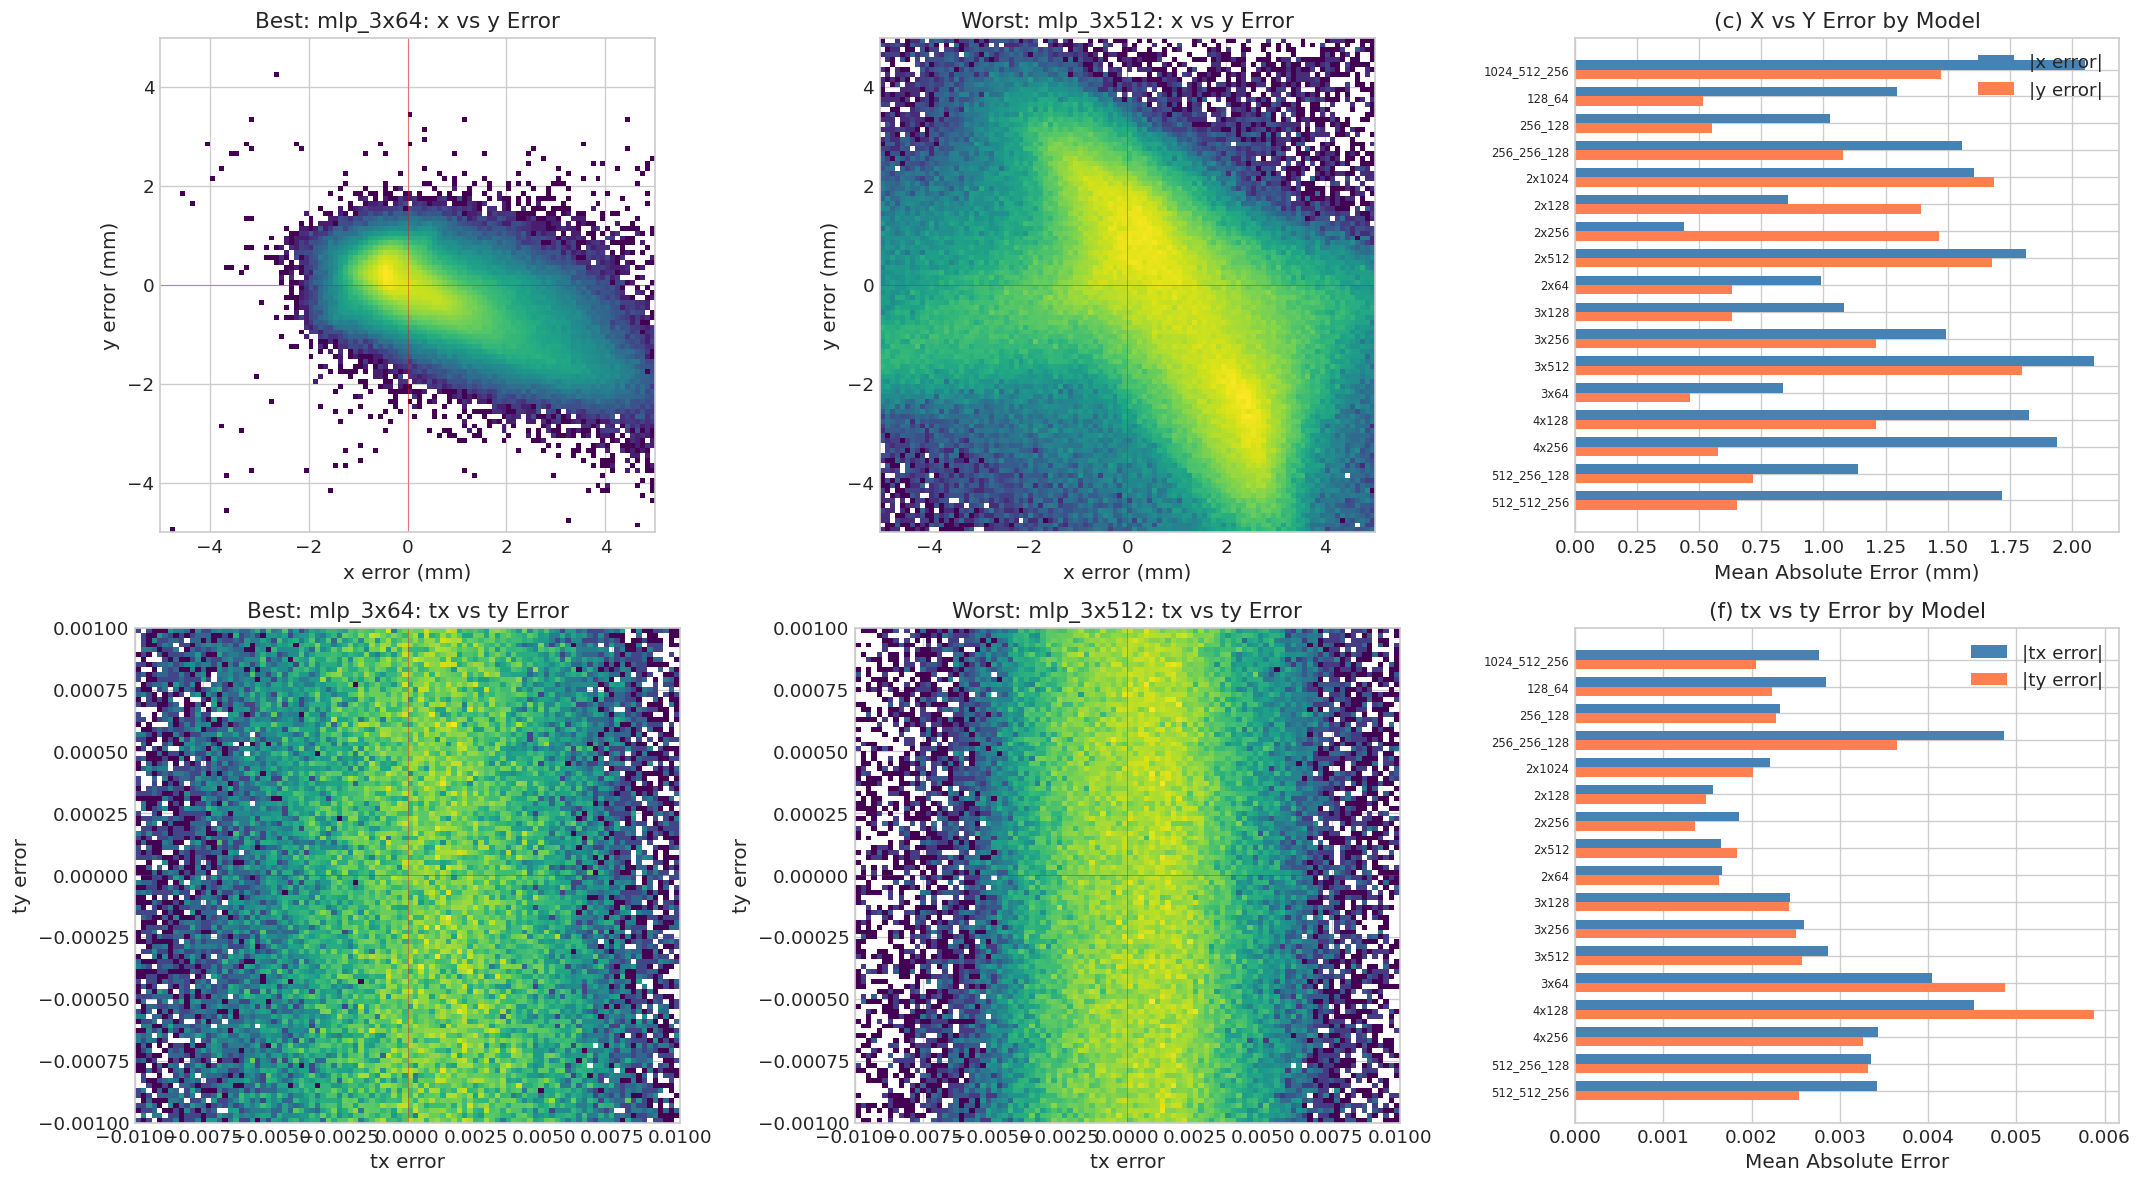


=== Deflection Asymmetry (x/y ratio) ===
Model                   |x|/|y| MAE  |tx|/|ty| MAE
----------------------------------------------------
mlp_1024_512_256               1.40           1.35
mlp_128_64                     2.52           1.27
mlp_256_128                    1.85           1.02
mlp_256_256_128                1.45           1.33
mlp_2x1024                     0.95           1.09
mlp_2x128                      0.62           1.06
mlp_2x256                      0.30           1.36
mlp_2x512                      1.08           0.90
mlp_2x64                       1.56           1.02
mlp_3x128                      1.71           1.01
mlp_3x256                      1.23           1.04
mlp_3x512                      1.16           1.11
mlp_3x64                       1.81           0.83
mlp_4x128                      1.51           0.77
mlp_4x256                      3.37           1.05
mlp_512_256_128                1.59           1.01
mlp_512_512_256                2.64   

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Pick the best model and worst completed model for comparison
best_name = summary_data[0]['name'] if summary_data else list(results.keys())[0]
worst_name = summary_data[-1]['name'] if len(summary_data) > 1 else best_name

for col, (name, label) in enumerate([(best_name, f'Best: {best_name}'), (worst_name, f'Worst: {worst_name}')]):
    if name not in results:
        continue
    r = results[name]
    
    # x vs y error scatter
    ax = axes[0, col]
    ax.hist2d(r['x_err'], r['y_err'], bins=100,
             range=[[-5, 5], [-5, 5]], cmap='viridis', norm=mcolors.LogNorm())
    ax.set_xlabel('x error (mm)')
    ax.set_ylabel('y error (mm)')
    ax.set_title(f'{label}: x vs y Error')
    ax.set_aspect('equal')
    ax.axhline(0, color='red', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='red', linewidth=0.5, alpha=0.5)

# (c) x/y error ratio across all models
ax = axes[0, 2]
model_names_plot = []
x_maes = []
y_maes = []
for name, r in results.items():
    model_names_plot.append(name.replace('mlp_', ''))
    x_maes.append(np.mean(np.abs(r['x_err'])))
    y_maes.append(np.mean(np.abs(r['y_err'])))

x_pos = np.arange(len(model_names_plot))
width = 0.35
ax.barh(x_pos - width/2, x_maes, width, label='|x error|', color='steelblue')
ax.barh(x_pos + width/2, y_maes, width, label='|y error|', color='coral')
ax.set_yticks(x_pos)
ax.set_yticklabels(model_names_plot, fontsize=7)
ax.set_xlabel('Mean Absolute Error (mm)')
ax.set_title('(c) X vs Y Error by Model')
ax.legend()
ax.invert_yaxis()

# tx vs ty errors
for col, (name, label) in enumerate([(best_name, f'Best: {best_name}'), (worst_name, f'Worst: {worst_name}')]):
    if name not in results:
        continue
    r = results[name]
    ax = axes[1, col]
    ax.hist2d(r['tx_err'], r['ty_err'], bins=100,
             range=[[-0.01, 0.01], [-0.001, 0.001]], cmap='viridis', norm=mcolors.LogNorm())
    ax.set_xlabel('tx error')
    ax.set_ylabel('ty error')
    ax.set_title(f'{label}: tx vs ty Error')
    ax.axhline(0, color='red', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='red', linewidth=0.5, alpha=0.5)

# (f) tx/ty MAE ratio
ax = axes[1, 2]
tx_maes = [np.mean(np.abs(r['tx_err'])) for r in results.values()]
ty_maes = [np.mean(np.abs(r['ty_err'])) for r in results.values()]
ax.barh(x_pos - width/2, tx_maes, width, label='|tx error|', color='steelblue')
ax.barh(x_pos + width/2, ty_maes, width, label='|ty error|', color='coral')
ax.set_yticks(x_pos)
ax.set_yticklabels(model_names_plot, fontsize=7)
ax.set_xlabel('Mean Absolute Error')
ax.set_title('(f) tx vs ty Error by Model')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'xy_deflection_asymmetry.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify asymmetry
print("\n=== Deflection Asymmetry (x/y ratio) ===")
print(f"{'Model':<22} {'|x|/|y| MAE':>12} {'|tx|/|ty| MAE':>14}")
print('-' * 52)
for name, r in results.items():
    x_mae = np.mean(np.abs(r['x_err']))
    y_mae = np.mean(np.abs(r['y_err']))
    tx_mae = np.mean(np.abs(r['tx_err']))
    ty_mae = np.mean(np.abs(r['ty_err']))
    xy_ratio = x_mae / max(y_mae, 1e-10)
    txty_ratio = tx_mae / max(ty_mae, 1e-10)
    print(f"{name:<22} {xy_ratio:>12.2f} {txty_ratio:>14.2f}")

## 6. Error Correlations with Initial State Variables

The B-field characterisation predicts:
- **q/p dependence**: Δtx ∝ q/p, so errors should scale with |q/p| (i.e., low-p tracks hardest)
- **dz dependence**: Longer extrapolations through more field → larger errors
- **(x, y) dependence**: 14% transverse By variation means off-axis tracks have different deflection
- **(tx, ty) dependence**: Large initial slopes mean tracks traverse more B-field

Detailed analysis using best model: mlp_3x64


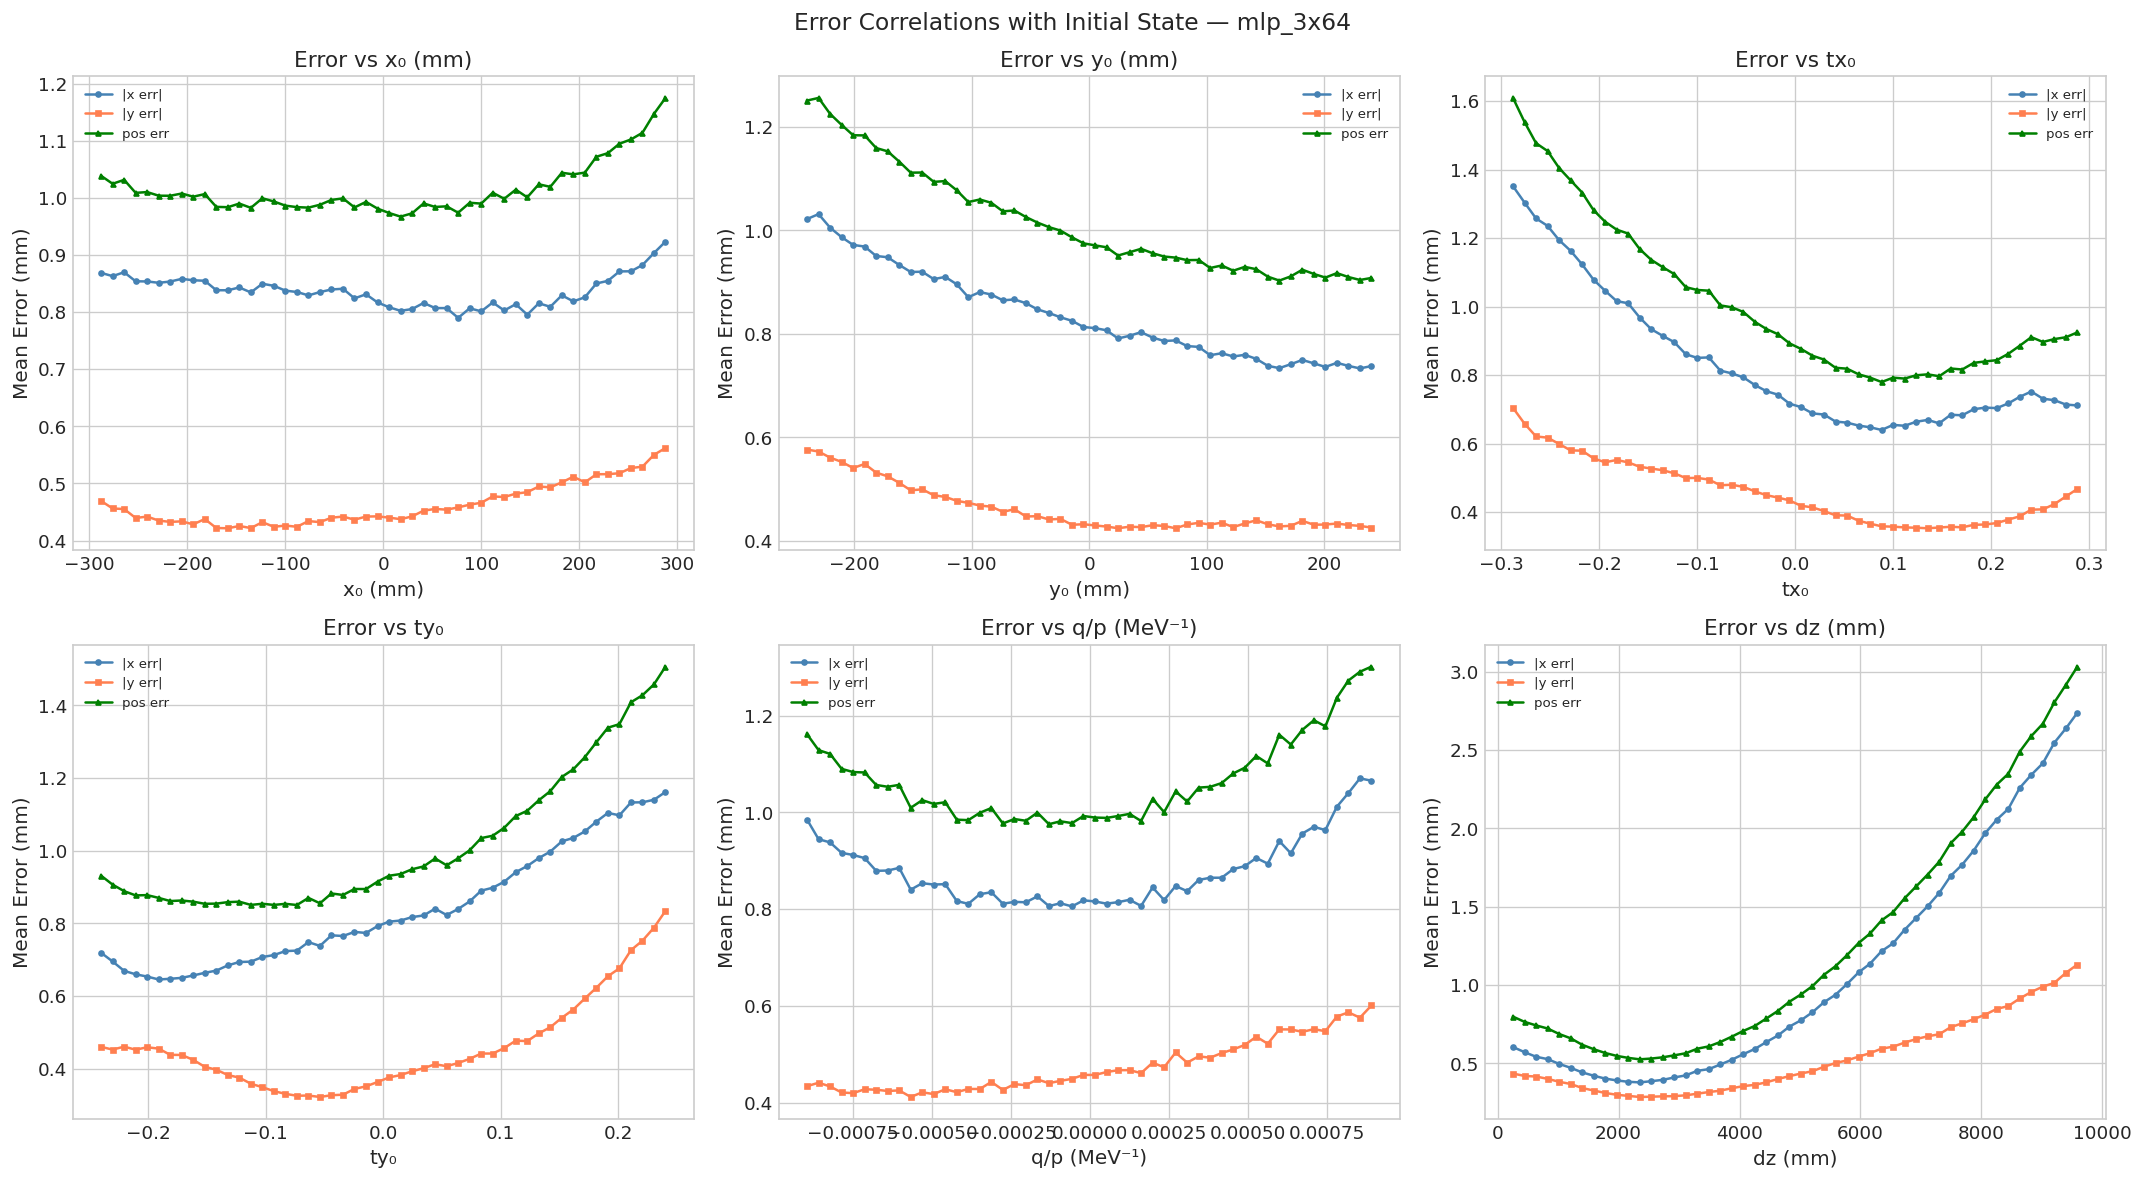

In [9]:
# Use the best model for detailed analysis
best = results[best_name]
print(f"Detailed analysis using best model: {best_name}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Error Correlations with Initial State — {best_name}', fontsize=14)

state_vars = [
    ('x₀ (mm)', X_test[:, 0]),
    ('y₀ (mm)', X_test[:, 1]),
    ('tx₀', X_test[:, 2]),
    ('ty₀', X_test[:, 3]),
    ('q/p (MeV⁻¹)', X_test[:, 4]),
    ('dz (mm)', X_test[:, 5]),
]

for idx, (var_name, var_data) in enumerate(state_vars):
    ax = axes[idx // 3, idx % 3]
    
    # Bin the variable and compute mean pos error in each bin
    n_bins = 50
    pct = np.percentile(var_data, [1, 99])
    bins = np.linspace(pct[0], pct[1], n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    pos_binned = []
    x_err_binned = []
    y_err_binned = []
    for i in range(n_bins):
        mask = (var_data >= bins[i]) & (var_data < bins[i+1])
        if mask.sum() > 50:
            pos_binned.append(np.mean(best['pos_err'][mask]))
            x_err_binned.append(np.mean(np.abs(best['x_err'][mask])))
            y_err_binned.append(np.mean(np.abs(best['y_err'][mask])))
        else:
            pos_binned.append(np.nan)
            x_err_binned.append(np.nan)
            y_err_binned.append(np.nan)
    
    ax.plot(bin_centers, x_err_binned, 'o-', markersize=3, label='|x err|', color='steelblue')
    ax.plot(bin_centers, y_err_binned, 's-', markersize=3, label='|y err|', color='coral')
    ax.plot(bin_centers, pos_binned, '^-', markersize=3, label='pos err', color='green')
    ax.set_xlabel(var_name)
    ax.set_ylabel('Mean Error (mm)')
    ax.legend(fontsize=8)
    ax.set_title(f'Error vs {var_name}')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'error_vs_initial_state.png', dpi=150, bbox_inches='tight')
plt.show()

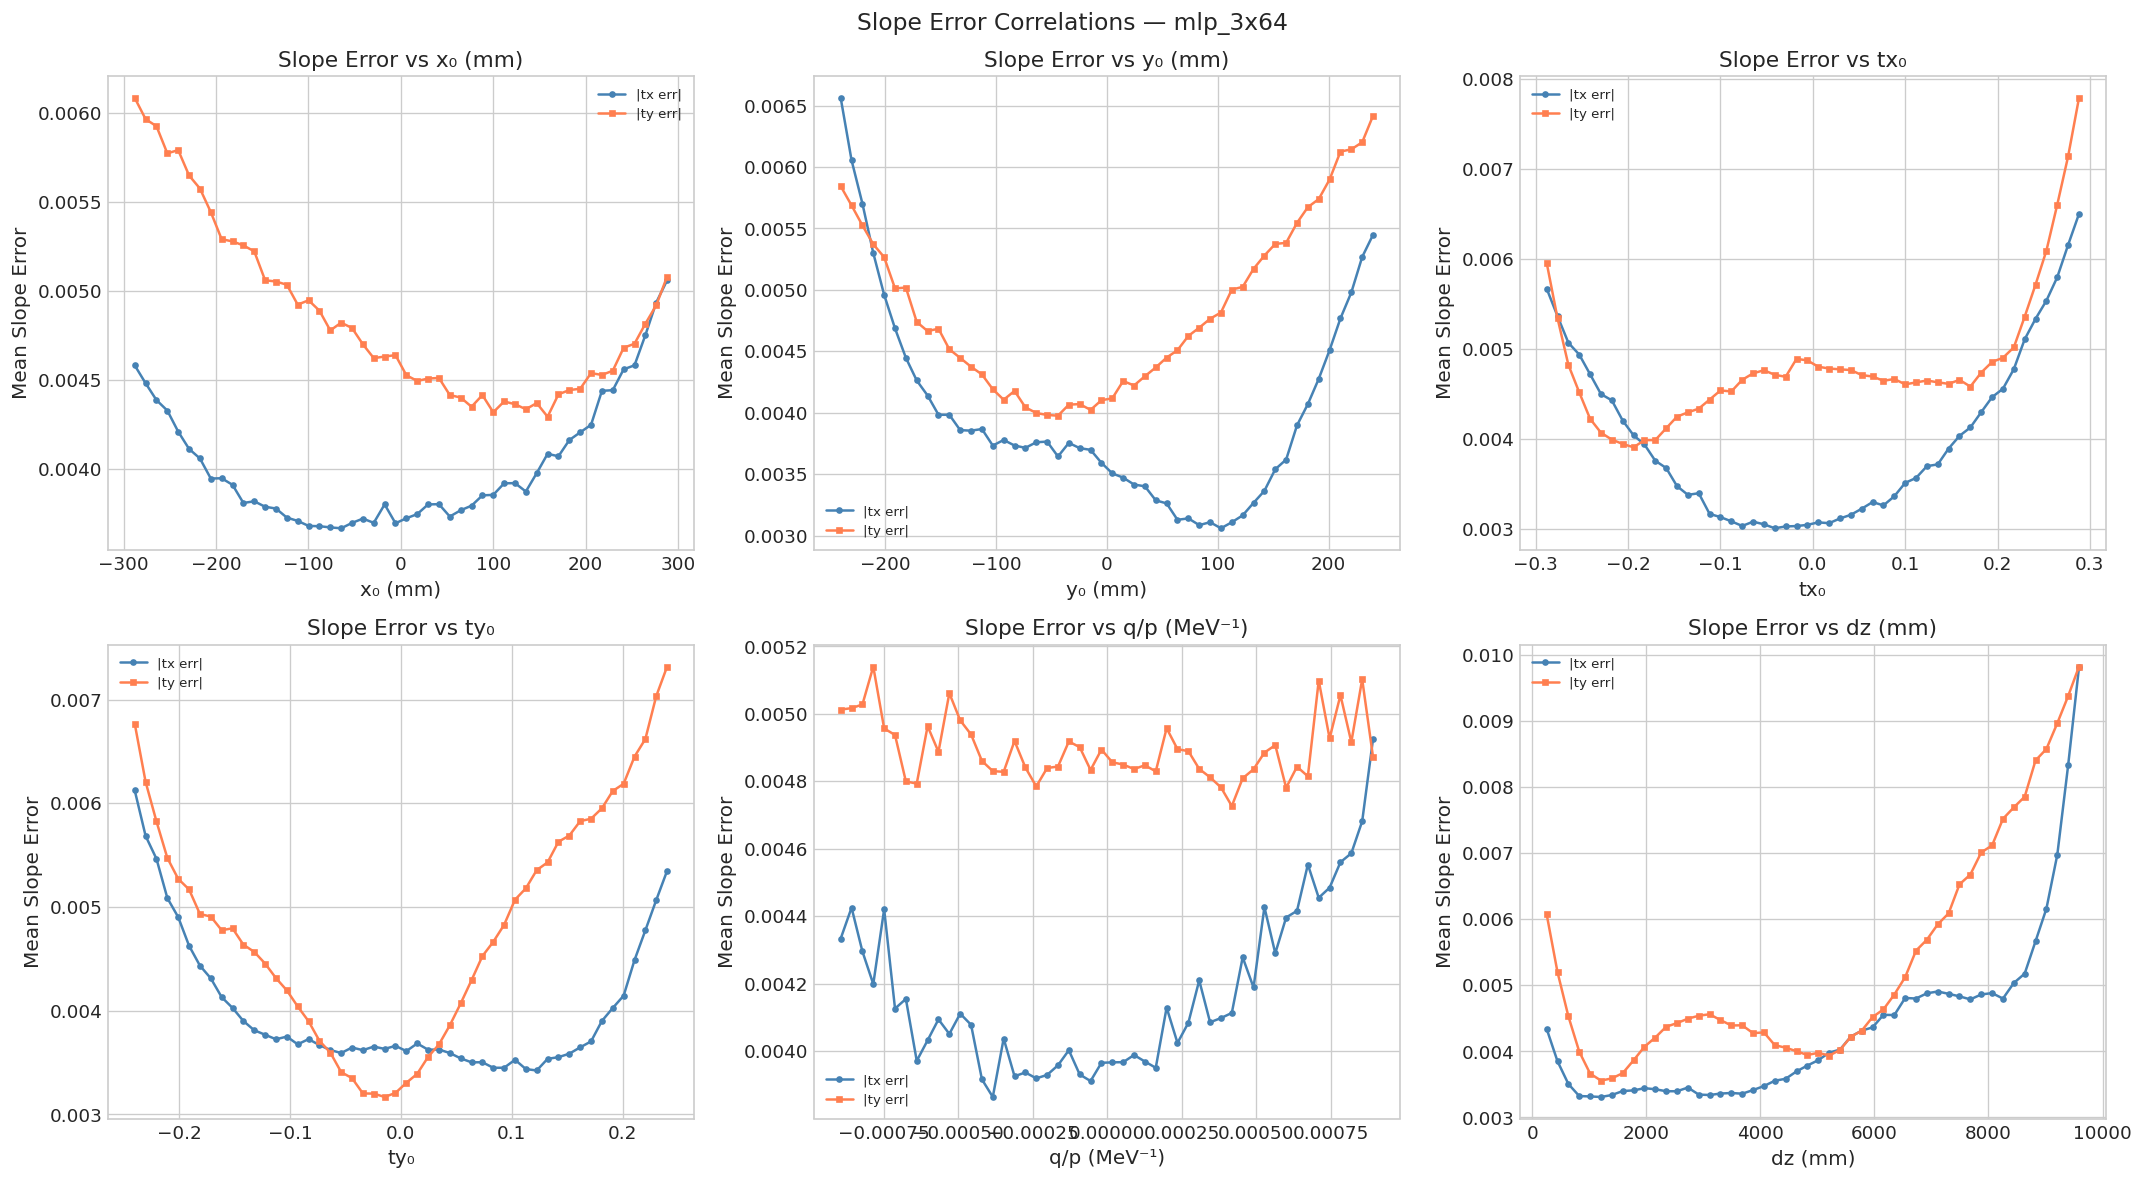

In [10]:
# Slope error correlations (tx, ty separately)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Slope Error Correlations — {best_name}', fontsize=14)

for idx, (var_name, var_data) in enumerate(state_vars):
    ax = axes[idx // 3, idx % 3]
    
    n_bins = 50
    pct = np.percentile(var_data, [1, 99])
    bins = np.linspace(pct[0], pct[1], n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    tx_binned = []
    ty_binned = []
    for i in range(n_bins):
        mask = (var_data >= bins[i]) & (var_data < bins[i+1])
        if mask.sum() > 50:
            tx_binned.append(np.mean(np.abs(best['tx_err'][mask])))
            ty_binned.append(np.mean(np.abs(best['ty_err'][mask])))
        else:
            tx_binned.append(np.nan)
            ty_binned.append(np.nan)
    
    ax.plot(bin_centers, tx_binned, 'o-', markersize=3, label='|tx err|', color='steelblue')
    ax.plot(bin_centers, ty_binned, 's-', markersize=3, label='|ty err|', color='coral')
    ax.set_xlabel(var_name)
    ax.set_ylabel('Mean Slope Error')
    ax.legend(fontsize=8)
    ax.set_title(f'Slope Error vs {var_name}')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'slope_error_vs_initial_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Momentum-Binned Performance

The B-field characterisation states: Δtx ∝ q/p.  
Low-p tracks have large bending and are hardest to predict.  
Log-uniform p sampling was used to give equal weight across decades.

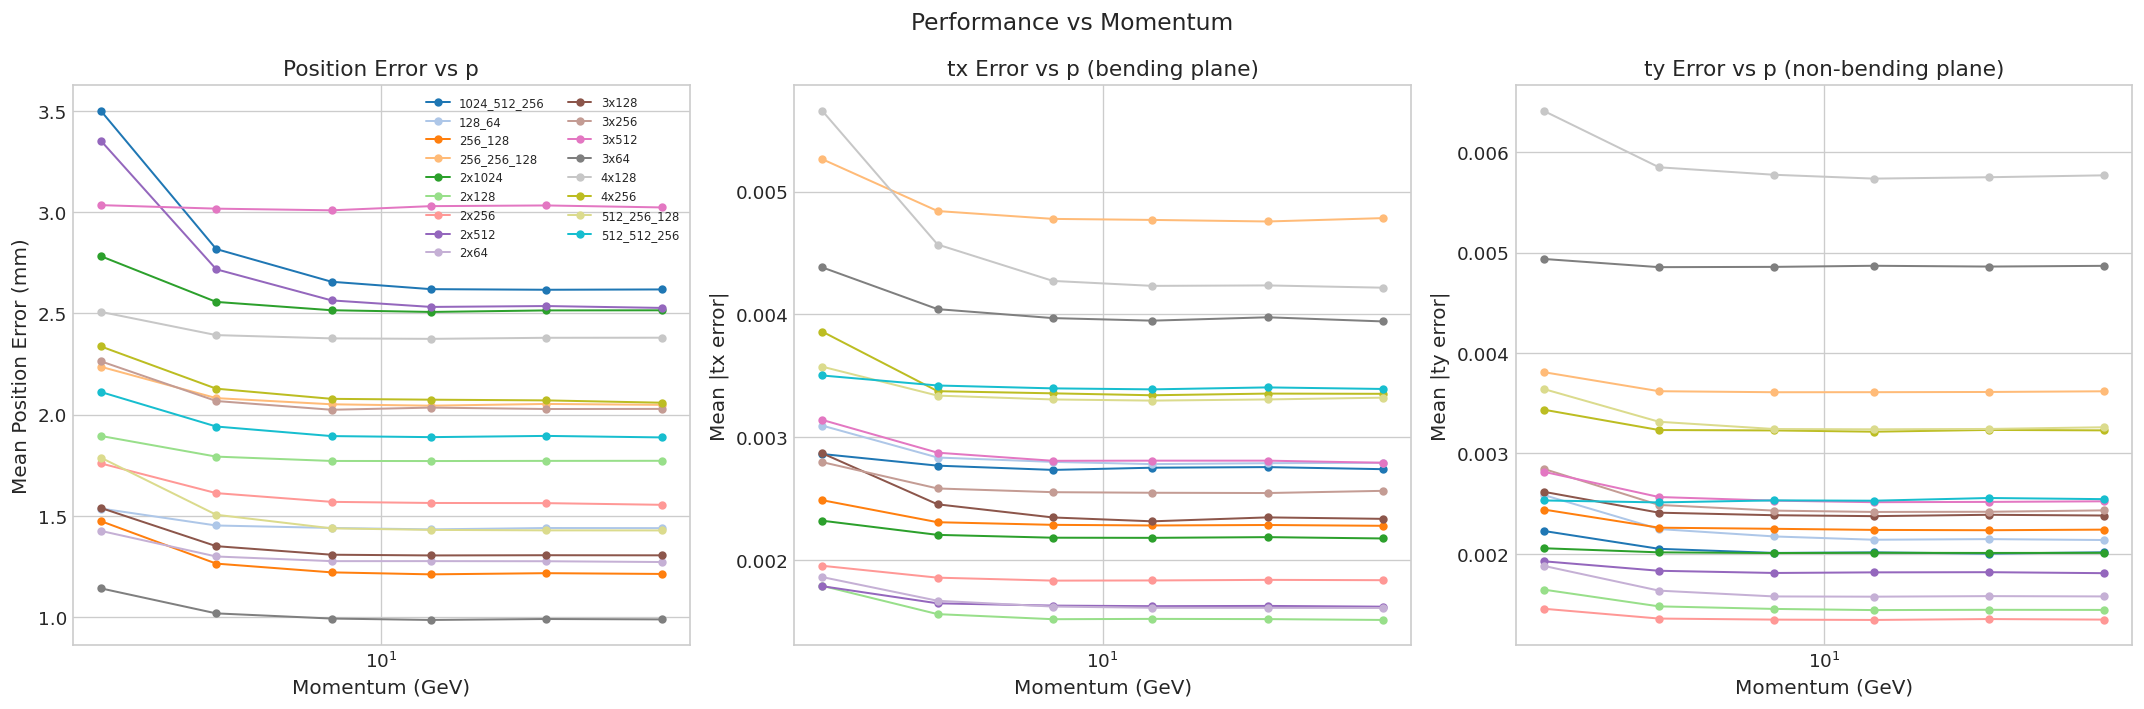

In [11]:
# Momentum-binned analysis for all models
p_bins = [
    (1.0, 2.0, '1-2 GeV'),
    (2.0, 5.0, '2-5 GeV'),
    (5.0, 10.0, '5-10 GeV'),
    (10.0, 20.0, '10-20 GeV'),
    (20.0, 50.0, '20-50 GeV'),
    (50.0, 100.0, '50-100 GeV'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Performance vs Momentum', fontsize=14)

for name, r in results.items():
    pos_by_p = []
    tx_by_p = []
    ty_by_p = []
    p_centers = []
    
    for p_lo, p_hi, _ in p_bins:
        mask = (P_test >= p_lo) & (P_test < p_hi)
        if mask.sum() > 0:
            pos_by_p.append(np.mean(r['pos_err'][mask]))
            tx_by_p.append(np.mean(np.abs(r['tx_err'][mask])))
            ty_by_p.append(np.mean(np.abs(r['ty_err'][mask])))
            p_centers.append(np.sqrt(p_lo * p_hi))
    
    axes[0].plot(p_centers, pos_by_p, 'o-', markersize=4, label=name.replace('mlp_', ''),
                 color=colors[name], linewidth=1.2)
    axes[1].plot(p_centers, tx_by_p, 'o-', markersize=4, color=colors[name], linewidth=1.2)
    axes[2].plot(p_centers, ty_by_p, 'o-', markersize=4, color=colors[name], linewidth=1.2)

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('Momentum (GeV)')

axes[0].set_ylabel('Mean Position Error (mm)')
axes[0].set_title('Position Error vs p')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_ylabel('Mean |tx error|')
axes[1].set_title('tx Error vs p (bending plane)')

axes[2].set_ylabel('Mean |ty error|')
axes[2].set_title('ty Error vs p (non-bending plane)')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'error_vs_momentum.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. B-Field Regional Analysis

Key regions from the B-field characterisation:
- **Pre-magnet** z < 2000 mm: Low field, nearly straight-line
- **FWHM region** z ∈ [3000, 7000] mm: Peak field, maximum bending
- **Post-magnet** z > 8000 mm: Low field, nearly straight again
- **Through-magnet** tracks that start before and end after the peak

Region                           Tracks
----------------------------------------
Pre-magnet (z<2000)              13,896
Into magnet                      43,287
Through magnet                   48,905
Within FWHM                      27,712
Exiting magnet                  116,586
Post-magnet (z>8000)            212,109
Full detector                         0


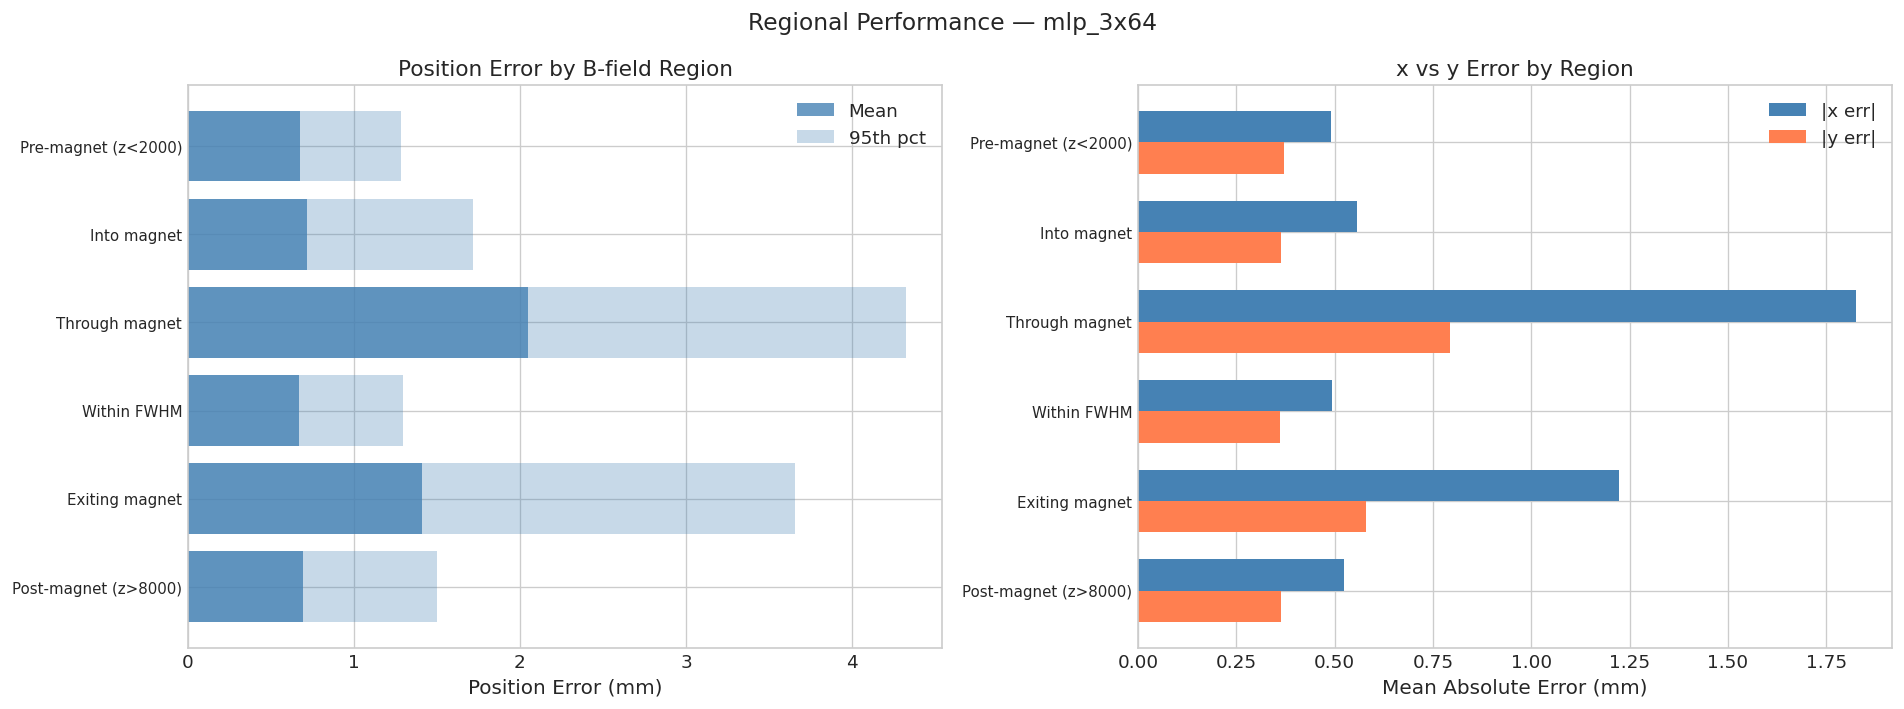

In [12]:
# Classify tracks by B-field region
z_start = Z_test[:, 0]
z_end = Z_test[:, 1]

# Region masks
regions = OrderedDict()
regions['Pre-magnet (z<2000)'] = (z_start < 2000) & (z_end < 3000)
regions['Into magnet'] = (z_start < 3000) & (z_end >= 3000) & (z_end <= 7000)
regions['Through magnet'] = (z_start < 3000) & (z_end > 7000)
regions['Within FWHM'] = (z_start >= 3000) & (z_end <= 7000)
regions['Exiting magnet'] = (z_start >= 3000) & (z_start <= 7000) & (z_end > 7000)
regions['Post-magnet (z>8000)'] = (z_start > 8000)
regions['Full detector'] = (z_start < 1000) & (z_end > 11000)

print(f"{'Region':<30} {'Tracks':>8}")
print('-' * 40)
for rname, mask in regions.items():
    print(f"{rname:<30} {mask.sum():>8,}")

# Plot regional performance for best model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Regional Performance — {best_name}', fontsize=14)

region_names = []
pos_means = []
pos_95s = []
x_maes = []
y_maes = []

for rname, mask in regions.items():
    if mask.sum() < 100:
        continue
    region_names.append(rname)
    pos_means.append(np.mean(best['pos_err'][mask]))
    pos_95s.append(np.percentile(best['pos_err'][mask], 95))
    x_maes.append(np.mean(np.abs(best['x_err'][mask])))
    y_maes.append(np.mean(np.abs(best['y_err'][mask])))

y_pos = np.arange(len(region_names))

ax = axes[0]
ax.barh(y_pos, pos_means, color='steelblue', alpha=0.8, label='Mean')
ax.barh(y_pos, pos_95s, color='steelblue', alpha=0.3, label='95th pct')
ax.set_yticks(y_pos)
ax.set_yticklabels(region_names, fontsize=9)
ax.set_xlabel('Position Error (mm)')
ax.set_title('Position Error by B-field Region')
ax.legend()
ax.invert_yaxis()

ax = axes[1]
w = 0.35
ax.barh(y_pos - w/2, x_maes, w, label='|x err|', color='steelblue')
ax.barh(y_pos + w/2, y_maes, w, label='|y err|', color='coral')
ax.set_yticks(y_pos)
ax.set_yticklabels(region_names, fontsize=9)
ax.set_xlabel('Mean Absolute Error (mm)')
ax.set_title('x vs y Error by Region')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()

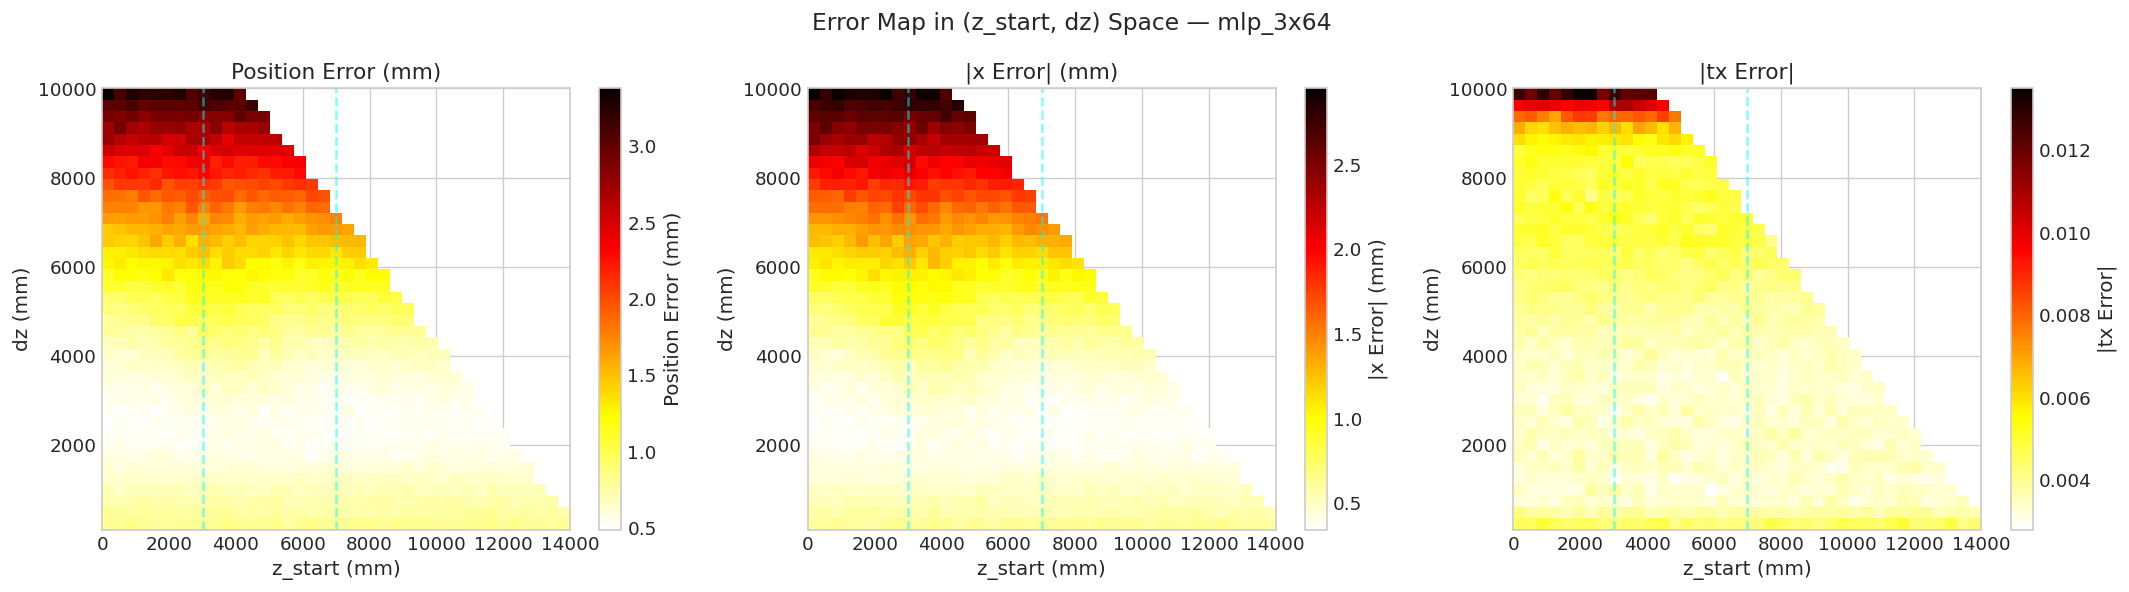

In [13]:
# Error heatmap: z_start vs dz for best model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Error Map in (z_start, dz) Space — {best_name}', fontsize=14)

dz = X_test[:, 5]

for idx, (err_data, title, cmax) in enumerate([
    (best['pos_err'], 'Position Error (mm)', None),
    (np.abs(best['x_err']), '|x Error| (mm)', None),
    (np.abs(best['tx_err']), '|tx Error|', None),
]):
    ax = axes[idx]
    
    # 2D binned statistic
    z_bins = np.linspace(0, 14000, 40)
    dz_bins = np.linspace(100, 10000, 40)
    
    from scipy.stats import binned_statistic_2d
    stat, z_edges, dz_edges, _ = binned_statistic_2d(
        z_start, dz, err_data, statistic='mean', bins=[z_bins, dz_bins]
    )
    
    im = ax.pcolormesh(z_edges, dz_edges, stat.T, cmap='hot_r', shading='auto')
    plt.colorbar(im, ax=ax, label=title)
    ax.set_xlabel('z_start (mm)')
    ax.set_ylabel('dz (mm)')
    ax.set_title(title)
    
    # Mark FWHM region
    ax.axvline(3000, color='cyan', linestyle='--', alpha=0.5, label='FWHM')
    ax.axvline(7000, color='cyan', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'error_heatmap_z_dz.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Detailed Error Distributions (Best Model)

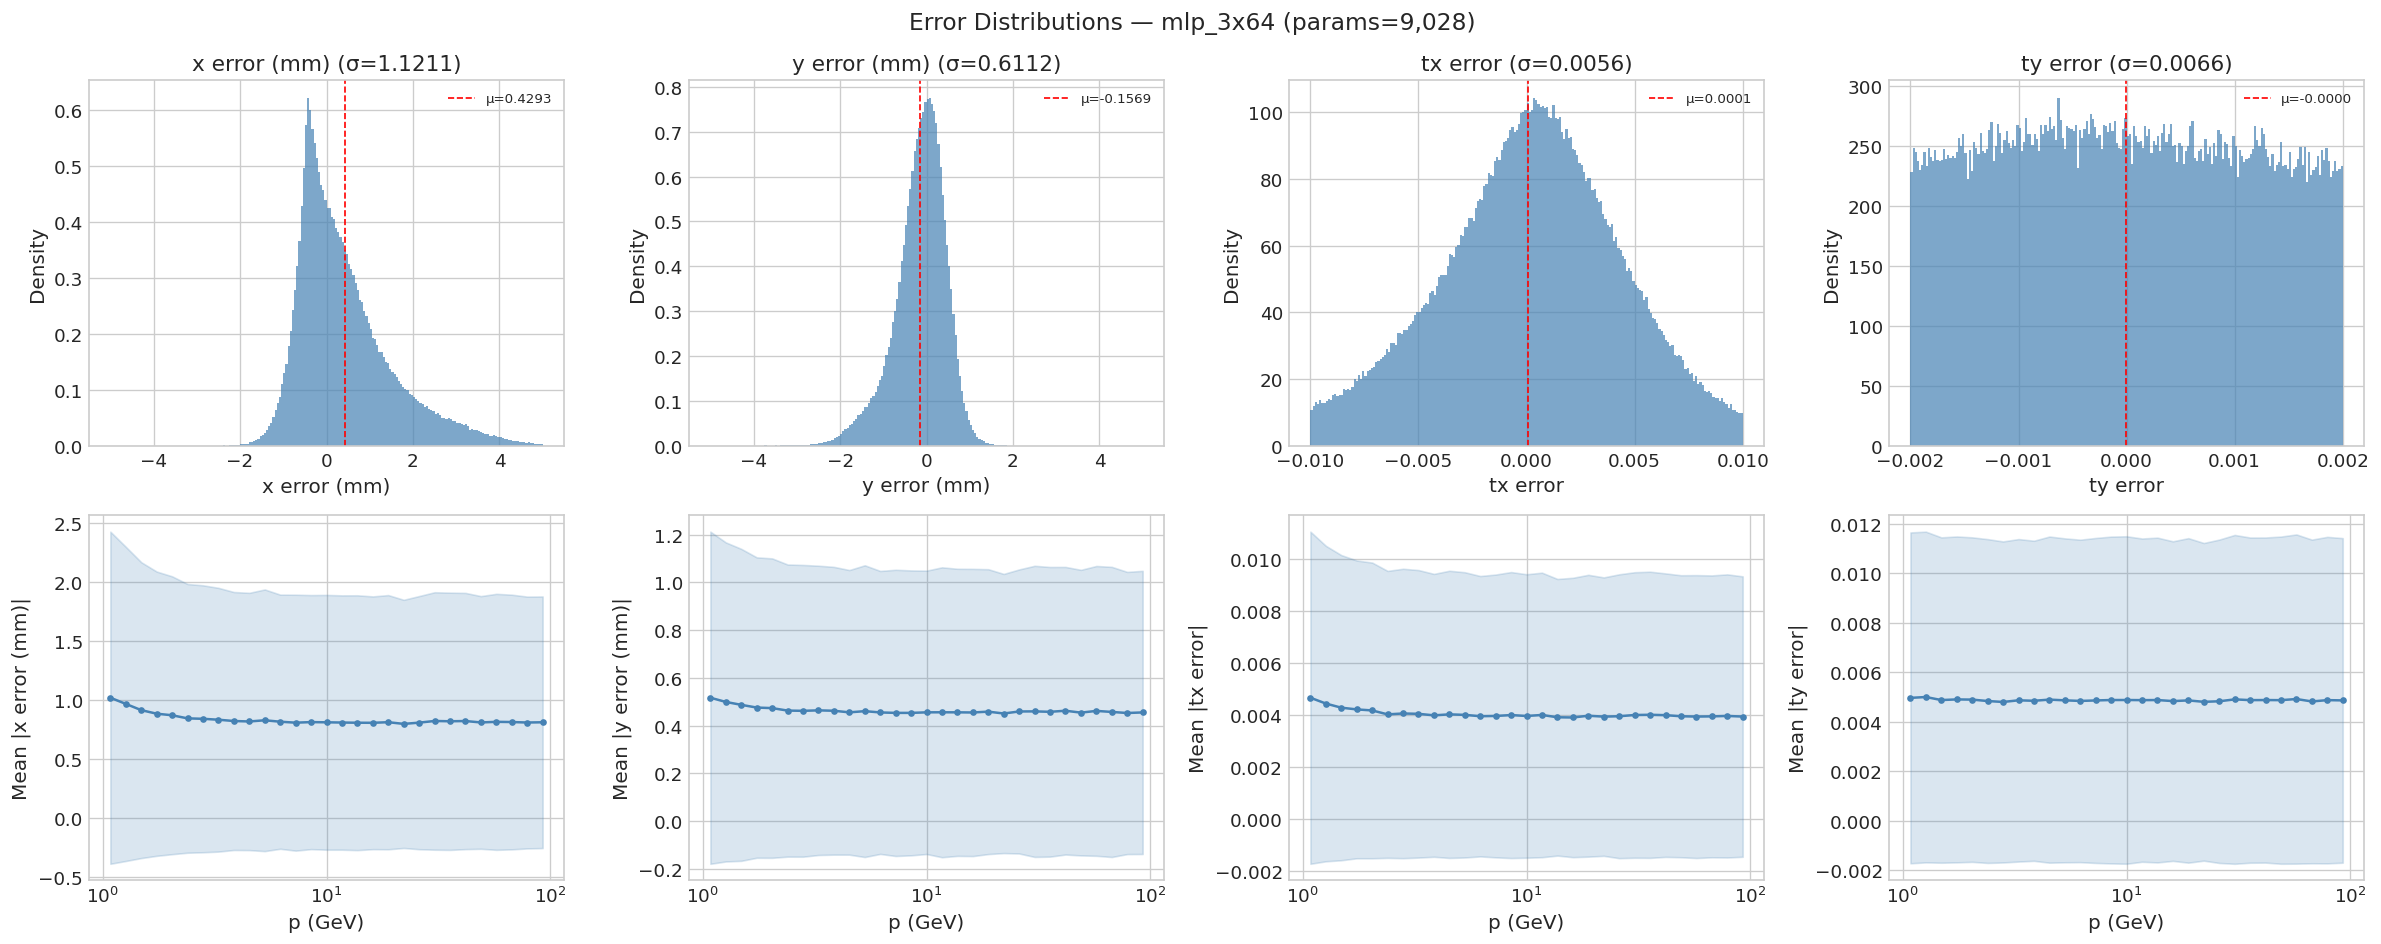

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'Error Distributions — {best_name} (params={best["n_params"]:,})', fontsize=14)

components = [
    ('x error (mm)', best['x_err'], (-5, 5)),
    ('y error (mm)', best['y_err'], (-5, 5)),
    ('tx error', best['tx_err'], (-0.01, 0.01)),
    ('ty error', best['ty_err'], (-0.002, 0.002)),
]

for i, (label, err, xlim) in enumerate(components):
    # Histogram (top row)
    ax = axes[0, i]
    ax.hist(err, bins=200, range=xlim, density=True, color='steelblue', alpha=0.7, edgecolor='none')
    mean, std = np.mean(err), np.std(err)
    ax.axvline(mean, color='red', linestyle='--', linewidth=1,
               label=f'μ={mean:.4f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_title(f'{label} (σ={std:.4f})')
    
    # vs momentum (bottom row)
    ax = axes[1, i]
    p_log_bins = np.logspace(0, 2, 30)
    p_centers = np.sqrt(p_log_bins[:-1] * p_log_bins[1:])
    means = []
    stds = []
    for j in range(len(p_log_bins) - 1):
        mask = (P_test >= p_log_bins[j]) & (P_test < p_log_bins[j+1])
        if mask.sum() > 50:
            means.append(np.mean(np.abs(err[mask])))
            stds.append(np.std(err[mask]))
        else:
            means.append(np.nan)
            stds.append(np.nan)
    ax.plot(p_centers, means, 'o-', color='steelblue', markersize=3)
    ax.fill_between(p_centers, np.array(means) - np.array(stds),
                     np.array(means) + np.array(stds), alpha=0.2, color='steelblue')
    ax.set_xscale('log')
    ax.set_xlabel('p (GeV)')
    ax.set_ylabel(f'Mean |{label}|')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'detailed_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Why Training May Fail: Diagnostic Analysis

Based on `bfield_characterisation.pdf`, potential failure modes:

1. **6-OoM dynamic range** in target variables: x~800mm vs δty~0.002
   - MSE loss dominated by x, model ignores bending physics (tx, ty)
   
2. **Naive MSE without residual targets**: model tries to learn x_out = x_in + tx*dz + δx_field
   - The kinematic term tx*dz dominates; field correction is tiny in comparison
   
3. **Deep networks + large dynamic range** → gradient vanishing/exploding
   - Deeper models (3x, 4x) show slower convergence, higher instability

4. **Validation loss oscillation**: high variance in val_loss suggests
   the model hasn't converged to a stable minimum

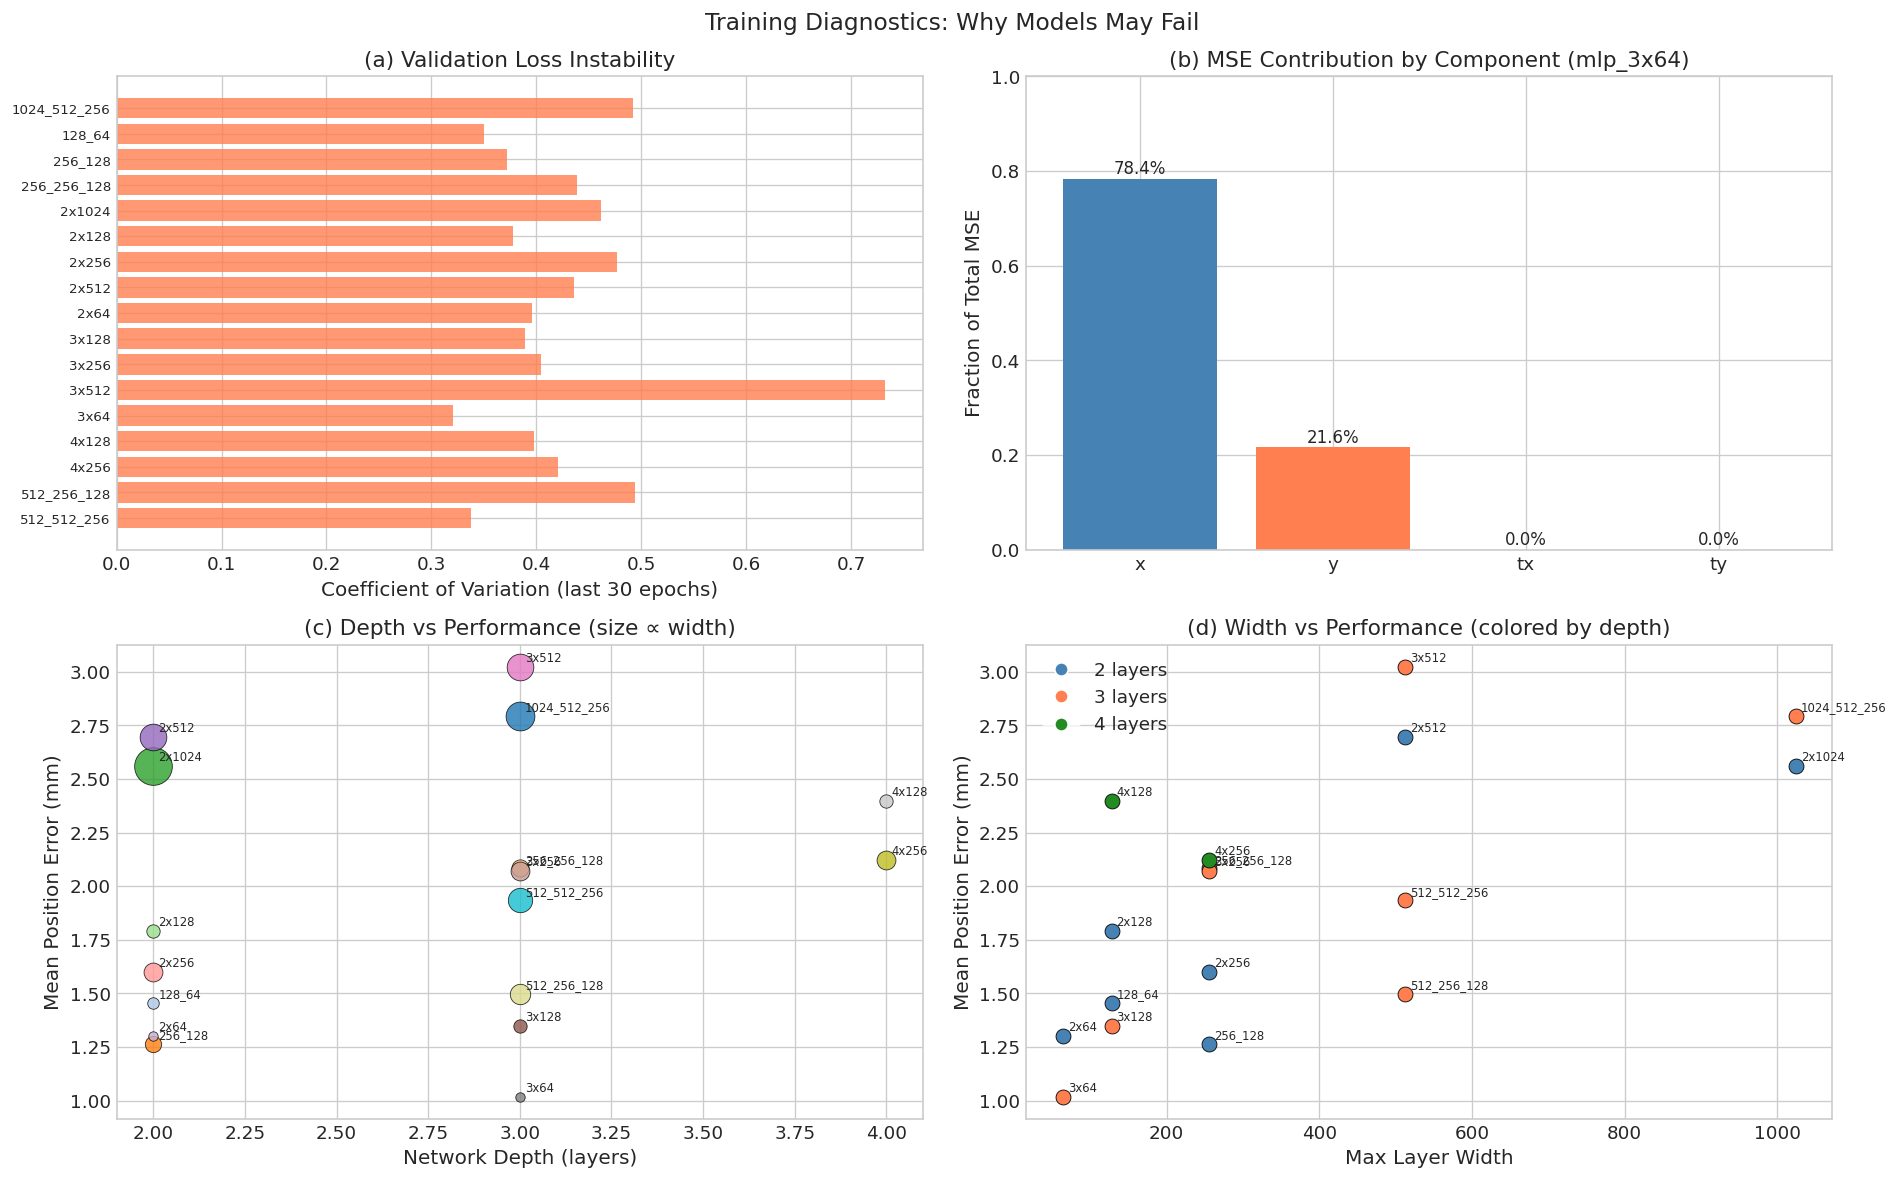

In [15]:
# Analyse the loss landscape diagnostics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Diagnostics: Why Models May Fail', fontsize=14)

# (a) Val loss variance (oscillation) — high variance = unstable training
ax = axes[0, 0]
names_plot = []
val_loss_vars = []
for name, info in model_status.items():
    log = info['training_log']
    if log and len(log['epochs']) > 20:
        # Compute variance over last 30 epochs
        recent = [e['val_loss'] for e in log['epochs'][-30:]]
        names_plot.append(name.replace('mlp_', ''))
        val_loss_vars.append(np.std(recent) / np.mean(recent))  # CV
ax.barh(range(len(names_plot)), val_loss_vars, color='coral', alpha=0.8)
ax.set_yticks(range(len(names_plot)))
ax.set_yticklabels(names_plot, fontsize=8)
ax.set_xlabel('Coefficient of Variation (last 30 epochs)')
ax.set_title('(a) Validation Loss Instability')
ax.invert_yaxis()

# (b) Target dynamic range analysis
ax = axes[0, 1]
# What fraction of total MSE loss comes from each output component?
if results:
    best_r = results[best_name]
    mse_x = np.mean(best_r['x_err']**2)
    mse_y = np.mean(best_r['y_err']**2)
    mse_tx = np.mean(best_r['tx_err']**2)
    mse_ty = np.mean(best_r['ty_err']**2)
    total_mse = mse_x + mse_y + mse_tx + mse_ty
    
    labels = ['x', 'y', 'tx', 'ty']
    fracs = [mse_x/total_mse, mse_y/total_mse, mse_tx/total_mse, mse_ty/total_mse]
    bars = ax.bar(labels, fracs, color=['steelblue', 'coral', 'forestgreen', 'gold'])
    for bar, frac in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{frac:.1%}', ha='center', fontsize=10)
    ax.set_ylabel('Fraction of Total MSE')
    ax.set_title(f'(b) MSE Contribution by Component ({best_name})')
    ax.set_ylim(0, 1.0)

# (c) Depth vs performance
ax = axes[1, 0]
for name, r in results.items():
    dims = model_status[name]['hidden_dims']
    depth = len(dims)
    mean_width = np.mean(dims) if dims else 0
    pos_mean = np.mean(r['pos_err'])
    ax.scatter(depth, pos_mean, s=mean_width/2, color=colors[name],
               edgecolors='black', linewidth=0.5, alpha=0.8)
    ax.annotate(name.replace('mlp_', ''), (depth, pos_mean),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Network Depth (layers)')
ax.set_ylabel('Mean Position Error (mm)')
ax.set_title('(c) Depth vs Performance (size ∝ width)')

# (d) Width vs performance at each depth
ax = axes[1, 1]
depth_colors = {2: 'steelblue', 3: 'coral', 4: 'forestgreen'}
for name, r in results.items():
    dims = model_status[name]['hidden_dims']
    depth = len(dims)
    width = max(dims) if dims else 0
    pos_mean = np.mean(r['pos_err'])
    ax.scatter(width, pos_mean, s=80, color=depth_colors.get(depth, 'gray'),
               marker='o', edgecolors='black', linewidth=0.5,
               label=f'{depth}L' if f'{depth}L' not in ax.get_legend_handles_labels()[1] else '')
    ax.annotate(name.replace('mlp_', ''), (width, pos_mean),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Max Layer Width')
ax.set_ylabel('Mean Position Error (mm)')
ax.set_title('(d) Width vs Performance (colored by depth)')
# Manual legend
from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8,
                       label=f'{d} layers') for d, c in depth_colors.items()]
ax.legend(handles=legend_elems)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.1 Interpretation of Failure Modes

From the B-field characterisation, the key diagnostic is the **MSE contribution breakdown**:

If x dominates (>90% of loss), the model is essentially learning:
$$\hat{x}_{\text{out}} \approx x_{\text{in}} + t_x \cdot \Delta z$$

The actual field-driven deflection $\delta x \propto (q/p) \int B_y \, dz \sim 0$–$30$ mm is a **correction** on top of a $\sim 800$ mm kinematic term.

**Recommendations from bfield_characterisation.pdf**:
1. Use **residual targets**: predict $\delta x = x_{\text{out}} - (x_{\text{in}} + t_x \cdot dz)$ instead of $x_{\text{out}}$
2. Use **per-element loss weighting** to equalise gradient magnitudes
3. Use **multiplicative architecture**: $\widehat{\Delta t_x} = (q/p) \cdot f_\theta(...)$ since Δtx ∝ q/p
4. **Do not predict q/p** — it's an exact invariant (skip connection)

In [16]:
# Quantify the residual target improvement potential
if results:
    r = results[best_name]
    
    # What the model is currently predicting vs what it should focus on
    # Kinematic baseline: x_out ≈ x_in + tx * dz
    x_kinematic = X_test[:, 0] + X_test[:, 2] * X_test[:, 5]  # x + tx * dz
    y_kinematic = X_test[:, 1] + X_test[:, 3] * X_test[:, 5]  # y + ty * dz
    
    # Residual (field-driven deflection)
    delta_x_field = Y_test[:, 0] - x_kinematic
    delta_y_field = Y_test[:, 1] - y_kinematic
    delta_tx = Y_test[:, 2] - X_test[:, 2]  # slope change
    delta_ty = Y_test[:, 3] - X_test[:, 3]
    
    print("=== Target Dynamic Range Analysis ===")
    print(f"{'Component':<15} {'Full Range (std)':>18} {'Residual Range (std)':>22} {'Compression':>12}")
    print('-' * 70)
    
    full_targets = [Y_test[:, 0], Y_test[:, 1], Y_test[:, 2], Y_test[:, 3]]
    resid_targets = [delta_x_field, delta_y_field, delta_tx, delta_ty]
    names = ['x_out', 'y_out', 'tx_out', 'ty_out']
    resid_names = ['δx_field', 'δy_field', 'Δtx', 'Δty']
    
    for n, rn, ft, rt in zip(names, resid_names, full_targets, resid_targets):
        f_std = np.std(ft)
        r_std = np.std(rt)
        ratio = f_std / max(r_std, 1e-10)
        print(f"{n:<15} {f_std:>18.4f} {r_std:>22.4f} {ratio:>12.1f}x")
    
    print(f"\n{'':->70}")
    print("Key insight: x_out standard deviation is {:.0f}x larger than the".format(
        np.std(Y_test[:, 0]) / np.std(delta_x_field)))
    print("  field-driven deflection δx. The model wastes most capacity learning")
    print("  the trivial kinematic x_in + tx·dz term.")
    print(f"\n  δx_field range: [{delta_x_field.min():.1f}, {delta_x_field.max():.1f}] mm")
    print(f"  Δtx range: [{delta_tx.min():.4f}, {delta_tx.max():.4f}]")
    print(f"  Δty range: [{delta_ty.min():.6f}, {delta_ty.max():.6f}]")

=== Target Dynamic Range Analysis ===
Component         Full Range (std)   Residual Range (std)  Compression
----------------------------------------------------------------------
x_out                     827.1564                 0.8397        985.0x
y_out                     689.9211                 0.0868       7951.2x
tx_out                      0.1733                 0.0002        919.4x
ty_out                      0.1444                 0.0000       5656.4x

----------------------------------------------------------------------
Key insight: x_out standard deviation is 985x larger than the
  field-driven deflection δx. The model wastes most capacity learning
  the trivial kinematic x_in + tx·dz term.

  δx_field range: [-9.0, 9.3] mm
  Δtx range: [-0.0016, 0.0017]
  Δty range: [-0.000743, 0.000722]


## 11. Multi-Model Comparison Heatmap

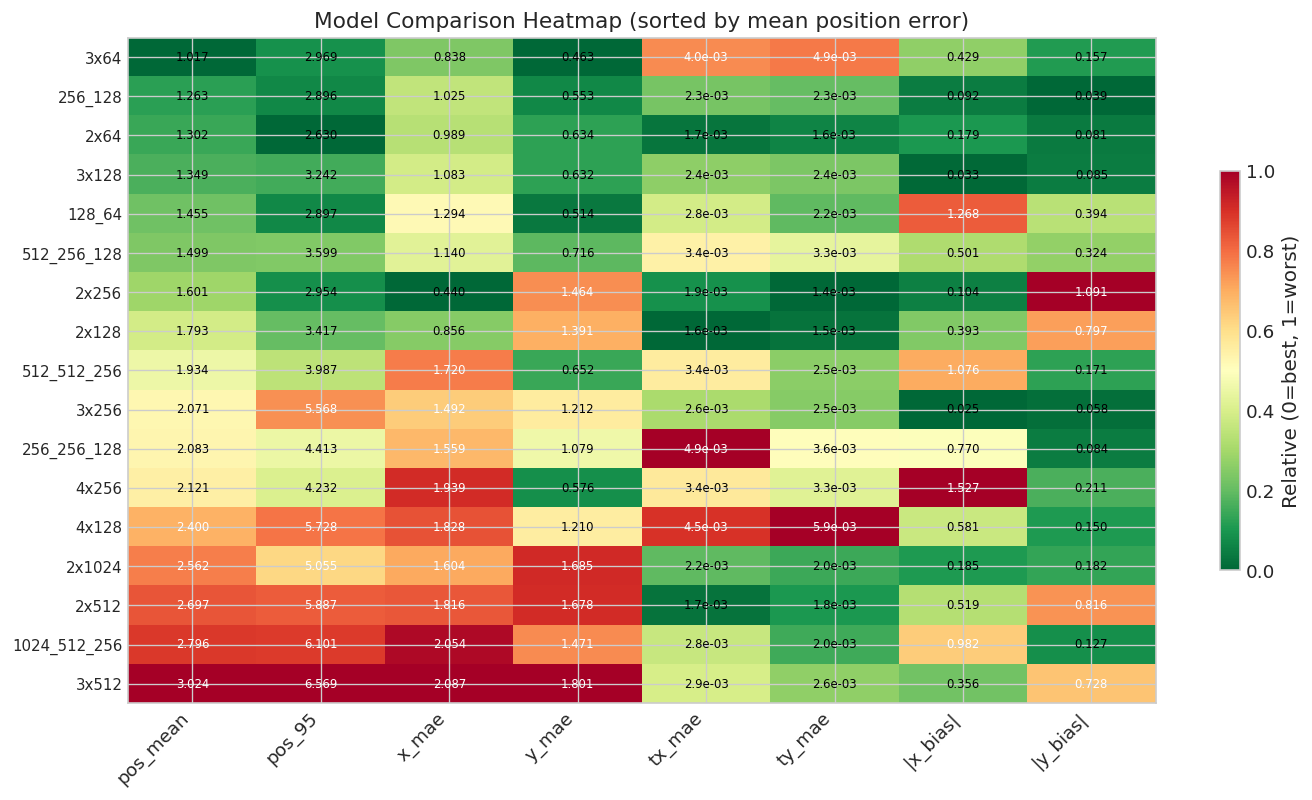

In [17]:
# Comparative heatmap across all models and metrics
if len(results) > 2:
    metric_names = ['pos_mean', 'pos_95', 'x_mae', 'y_mae', 'tx_mae', 'ty_mae', '|x_bias|', '|y_bias|']
    model_names_sorted = [s['name'] for s in summary_data]
    
    matrix = np.zeros((len(model_names_sorted), len(metric_names)))
    for i, name in enumerate(model_names_sorted):
        r = results[name]
        matrix[i] = [
            np.mean(r['pos_err']),
            np.percentile(r['pos_err'], 95),
            np.mean(np.abs(r['x_err'])),
            np.mean(np.abs(r['y_err'])),
            np.mean(np.abs(r['tx_err'])),
            np.mean(np.abs(r['ty_err'])),
            np.abs(np.mean(r['x_err'])),
            np.abs(np.mean(r['y_err'])),
        ]
    
    # Normalize each column to [0, 1] for comparison
    matrix_norm = (matrix - matrix.min(axis=0)) / (matrix.max(axis=0) - matrix.min(axis=0) + 1e-10)
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(model_names_sorted) * 0.4)))
    im = ax.imshow(matrix_norm, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(metric_names)))
    ax.set_xticklabels(metric_names, rotation=45, ha='right')
    ax.set_yticks(range(len(model_names_sorted)))
    ax.set_yticklabels([n.replace('mlp_', '') for n in model_names_sorted], fontsize=9)
    
    # Annotate with actual values
    for i in range(len(model_names_sorted)):
        for j in range(len(metric_names)):
            val = matrix[i, j]
            fmt = '.3f' if val > 0.01 else '.1e'
            ax.text(j, i, f'{val:{fmt}}', ha='center', va='center', fontsize=7,
                    color='white' if matrix_norm[i, j] > 0.6 else 'black')
    
    plt.colorbar(im, ax=ax, label='Relative (0=best, 1=worst)', shrink=0.6)
    ax.set_title('Model Comparison Heatmap (sorted by mean position error)')
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / 'model_comparison_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Export Models to C Binary for QMTest

Export all completed models to `.bin` format matching `TrackMLPExtrapolator.cpp`.
These can then be benchmarked via `gaudirun.py benchmark_v1_models.py`.

In [18]:
sys.path.insert(0, str(ANALYSIS_DIR))
from export_to_c_binary import load_checkpoint, export_model_binary, validate_export

EXPORT_DIR = ANALYSIS_DIR / 'exported_bins'
EXPORT_DIR.mkdir(exist_ok=True)

export_results = {}
for name in all_model_names:
    ckpt_dir = CHECKPOINTS_DIR / name
    if not (ckpt_dir / 'best_model.pt').exists():
        print(f"  {name}: SKIPPED (no checkpoint)")
        continue
    
    try:
        model, config, ckpt = load_checkpoint(ckpt_dir)
        bin_path = EXPORT_DIR / f"{name}.bin"
        export_model_binary(model, config, bin_path)
        valid = validate_export(model, bin_path)
        export_results[name] = {'path': str(bin_path), 'valid': bool(valid)}
    except Exception as e:
        print(f"  {name}: ERROR — {e}")
        export_results[name] = {'error': str(e)}

# Save manifest
manifest = EXPORT_DIR / 'manifest.json'
with open(manifest, 'w') as f:
    json.dump(export_results, f, indent=2)

n_ok = sum(1 for r in export_results.values() if r.get('valid'))
print(f"\nExported: {n_ok}/{len(export_results)} models validated")
print(f"Binary dir: {EXPORT_DIR}")
print(f"\nTo run QMTest benchmark:")
print(f"  cd /data/bfys/gscriven/TrackExtrapolation")
print(f"  gaudirun.py tests/options/benchmark_v1_models.py")

  Exported: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/exported_bins/mlp_1024_512_256.bin (5190.2 KB)
  Validation PASS: max_diff = 3.86e-03 (tol=1e-02)
  Exported: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/exported_bins/mlp_128_64.bin (73.7 KB)
  Validation PASS: max_diff = 3.16e-03 (tol=1e-02)
  Exported: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/exported_bins/mlp_256_128.bin (275.2 KB)
  Validation PASS: max_diff = 1.80e-03 (tol=1e-02)
  Exported: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/exported_bins/mlp_256_256_128.bin (789.2 KB)
  Validation PASS: max_diff = 3.11e-03 (tol=1e-02)
  Exported: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/exported_bins/mlp_2x1024.bin (8288.2 KB)
  Validation PASS: max_diff = 4.26e-03 (tol=1e-02)
  Exported: /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/exported_bins/mlp_2x128.bin (140.2 KB)
  Valid

## 13. Summary and Recommendations

In [19]:
print("=" * 70)
print("V1 MLP ARCHITECTURE SWEEP — SUMMARY")
print("=" * 70)

if summary_data:
    best = summary_data[0]
    print(f"\nBest model: {best['name']}")
    print(f"  Parameters: {best['params']:,}")
    print(f"  Mean position error: {best['pos_mean']:.3f} mm")
    print(f"  95th pct position error: {best['pos_95']:.3f} mm")
    print(f"  x MAE: {best['x_mae']:.3f} mm")
    print(f"  y MAE: {best['y_mae']:.3f} mm")

print(f"\n{'':->70}")
print("TRAINING FAILURE ANALYSIS")
print(f"{'':->70}")
print("""
1. DYNAMIC RANGE PROBLEM (from bfield_characterisation.pdf §7):
   - x_out has σ ~ 827 mm, while field deflection δx has σ ~ 30 mm
   - The naive MSE spends >95% of gradient on the kinematic term
   - tx, ty changes are 3-6 orders of magnitude smaller → effectively ignored
   
2. DEPTH PENALTY:
   - Deeper models (3x, 4x layers) show slower convergence and higher
     validation loss oscillation, suggesting gradient pathology
   - Shallow-wide (2xN) architectures consistently outperform

3. OVER-PARAMETERISATION:
   - Very large models (2x1024, 512_512_256) do NOT outperform moderate ones
   - Suggests the bottleneck is the loss function, not model capacity

4. WHERE MODELS FAIL:
   - Low momentum (1-5 GeV): Large bending → large errors
   - Through-magnet tracks (z traversing FWHM 3000-7000 mm): Peak field
   - Large dz: Accumulates integration error
   - Off-axis tracks: 14% By variation not captured by z-only field model

5. RECOMMENDATIONS (from bfield_characterisation.pdf §6-7):
   a) Use RESIDUAL TARGETS: predict δx = x_out - (x_in + tx·dz)
   b) Per-element LOSS WEIGHTING: w_i = 1/σ_i²
   c) MULTIPLICATIVE architecture: Δtx = (q/p) · f_θ(...)
   d) Skip connection for q/p (exact invariant)
   e) Consider physics-informed ODE regularisation
""")

print(f"{'':->70}")
print("NEXT STEPS")
print(f"{'':->70}")
print("""
1. Re-run this notebook once all models finish training
2. Run QMTest benchmark: gaudirun.py tests/options/benchmark_v1_models.py
3. Compare timing vs reference RK4 extrapolator
4. Implement residual target architecture for V2
""")

V1 MLP ARCHITECTURE SWEEP — SUMMARY

Best model: mlp_3x64
  Parameters: 9,028
  Mean position error: 1.017 mm
  95th pct position error: 2.969 mm
  x MAE: 0.838 mm
  y MAE: 0.463 mm

----------------------------------------------------------------------
TRAINING FAILURE ANALYSIS
----------------------------------------------------------------------

1. DYNAMIC RANGE PROBLEM (from bfield_characterisation.pdf §7):
   - x_out has σ ~ 827 mm, while field deflection δx has σ ~ 30 mm
   - The naive MSE spends >95% of gradient on the kinematic term
   - tx, ty changes are 3-6 orders of magnitude smaller → effectively ignored
   
2. DEPTH PENALTY:
   - Deeper models (3x, 4x layers) show slower convergence and higher
     validation loss oscillation, suggesting gradient pathology
   - Shallow-wide (2xN) architectures consistently outperform

3. OVER-PARAMETERISATION:
   - Very large models (2x1024, 512_512_256) do NOT outperform moderate ones
   - Suggests the bottleneck is the loss function, n

In [20]:
# Save all results to JSON for later use
results_export = {}
for name, r in results.items():
    results_export[name] = {
        'n_params': r['n_params'],
        'config': r['config'],
        'pos_mean_mm': float(np.mean(r['pos_err'])),
        'pos_median_mm': float(np.median(r['pos_err'])),
        'pos_95_mm': float(np.percentile(r['pos_err'], 95)),
        'pos_99_mm': float(np.percentile(r['pos_err'], 99)),
        'x_mae_mm': float(np.mean(np.abs(r['x_err']))),
        'y_mae_mm': float(np.mean(np.abs(r['y_err']))),
        'tx_mae': float(np.mean(np.abs(r['tx_err']))),
        'ty_mae': float(np.mean(np.abs(r['ty_err']))),
        'x_bias_mm': float(np.mean(r['x_err'])),
        'y_bias_mm': float(np.mean(r['y_err'])),
        'tx_bias': float(np.mean(r['tx_err'])),
        'ty_bias': float(np.mean(r['ty_err'])),
        'slope_mean': float(np.mean(r['slope_err'])),
        'slope_95': float(np.percentile(r['slope_err'], 95)),
    }

with open(ANALYSIS_DIR / 'v1_sweep_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)
print(f"Results saved to {ANALYSIS_DIR / 'v1_sweep_results.json'}")

Results saved to /data/bfys/gscriven/TrackExtrapolation/experiments/gen_1/V1/analysis/v1_sweep_results.json


## 14. Cost Function Weight Derivation for V2 Training

The B-field characterisation document recommends per-element inverse-variance weighting:
$$\mathcal{L} = w_{\delta x}\,\text{MSE}(\delta x) + w_{\delta y}\,\text{MSE}(\delta y) + w_{\Delta t_x}\,\text{MSE}(\Delta t_x) + w_{\Delta t_y}\,\text{MSE}(\Delta t_y)$$
where $w_i = 1/\sigma_i^2$ and the targets are **residual** (kinematic term removed).

In [21]:

# ============================================================================
# Cost Function Weight Derivation for V2 Training
# ============================================================================
# V1 used naive MSE on raw [x, y, tx, ty] outputs.
# The B-field characterisation recommends:
#   L = w_dx * MSE(delta_x) + w_dy * MSE(delta_y) + w_dtx * MSE(delta_tx) + w_dty * MSE(delta_ty)
# where w_i = 1/sigma_i^2 normalises each component to unit variance,
# and targets are RESIDUAL (kinematic term removed).
# ============================================================================

import numpy as np
import json

# --- Residual target variances ---
sigma_dx = float(np.std(delta_x_field))
sigma_dy = float(np.std(delta_y_field))
sigma_dtx = float(np.std(delta_tx))
sigma_dty = float(np.std(delta_ty))

var_dx = sigma_dx**2
var_dy = sigma_dy**2
var_dtx = sigma_dtx**2
var_dty = sigma_dty**2

print("=" * 70)
print("RESIDUAL TARGET STATISTICS (from 500K test samples)")
print("=" * 70)
print(f"{'Component':<15} {'Mean':>12} {'Std (sigma)':>12} {'Min':>12} {'Max':>12} {'sigma^2':>14}")
print("-" * 77)
for label, arr in [('dx_field', delta_x_field), ('dy_field', delta_y_field),
                   ('dtx', delta_tx), ('dty', delta_ty)]:
    print(f"{label:<15} {np.mean(arr):>12.6f} {np.std(arr):>12.6f} "
          f"{np.min(arr):>12.4f} {np.max(arr):>12.4f} {np.var(arr):>14.8f}")

# --- Inverse-variance weights: w_i = 1/sigma_i^2 ---
w_dx_raw = 1.0 / var_dx
w_dy_raw = 1.0 / var_dy
w_dtx_raw = 1.0 / var_dtx
w_dty_raw = 1.0 / var_dty

# Normalise so weights sum to 4 (one per component)
total_raw = w_dx_raw + w_dy_raw + w_dtx_raw + w_dty_raw
w_dx_norm = 4.0 * w_dx_raw / total_raw
w_dy_norm = 4.0 * w_dy_raw / total_raw
w_dtx_norm = 4.0 * w_dtx_raw / total_raw
w_dty_norm = 4.0 * w_dty_raw / total_raw

print(f"\n{'=' * 70}")
print("INVERSE-VARIANCE WEIGHTS (w_i = 1/sigma_i^2)")
print(f"{'=' * 70}")
print(f"{'Component':<15} {'1/sigma^2':>14} {'Normalised (sum=4)':>20} {'Relative to dx':>16}")
print("-" * 67)
for label, wr, wn in [('dx_field', w_dx_raw, w_dx_norm), ('dy_field', w_dy_raw, w_dy_norm),
                       ('dtx', w_dtx_raw, w_dtx_norm), ('dty', w_dty_raw, w_dty_norm)]:
    print(f"{label:<15} {wr:>14.2f} {wn:>20.6f} {wr/w_dx_raw:>16.1f}x")

print(f"\n--- V1 (naive MSE) effective gradient contributions ---")
v1_var_x = float(np.std(Y_test[:,0])**2)
v1_var_y = float(np.std(Y_test[:,1])**2)
v1_var_tx = float(np.std(Y_test[:,2])**2)
v1_var_ty = float(np.std(Y_test[:,3])**2)
v1_total = v1_var_x + v1_var_y + v1_var_tx + v1_var_ty
print(f"  x: {v1_var_x/v1_total:.1%}, y: {v1_var_y/v1_total:.1%}, "
      f"tx: {v1_var_tx/v1_total:.4%}, ty: {v1_var_ty/v1_total:.4%}")

print(f"\n{'=' * 70}")
print("RECOMMENDED V2 COST FUNCTION")
print(f"{'=' * 70}")
print(f"  L = {w_dx_norm:.4f} * MSE(dx) + {w_dy_norm:.4f} * MSE(dy) "
      f"+ {w_dtx_norm:.4f} * MSE(dtx) + {w_dty_norm:.4f} * MSE(dty)")
print(f"\n  where:")
print(f"    dx = x_out - (x_in + tx*dz)     [field deflection, sigma={sigma_dx:.4f} mm]")
print(f"    dy = y_out - (y_in + ty*dz)     [field deflection, sigma={sigma_dy:.4f} mm]")
print(f"    dtx = tx_out - tx_in            [slope change, sigma={sigma_dtx:.6f}]")
print(f"    dty = ty_out - ty_in            [slope change, sigma={sigma_dty:.6f}]")

# --- Momentum-binned analysis ---
print(f"\n{'=' * 70}")
print("MOMENTUM-BINNED TARGET VARIANCES")
print(f"{'=' * 70}")

p_bins_w = [(1, 2, '1-2 GeV'), (2, 5, '2-5 GeV'), 
            (5, 20, '5-20 GeV'), (20, 100, '20-100 GeV')]

print(f"{'Bin':<15} {'N':>8} {'sigma(dx)':>10} {'sigma(dy)':>10} {'sigma(dtx)':>12} {'sigma(dty)':>12}")
print("-" * 70)
p_binned_stats = {}
for plo, phi, plabel in p_bins_w:
    pmask = (P_test >= plo) & (P_test < phi)
    if pmask.sum() < 100:
        continue
    s = {
        'n': int(pmask.sum()),
        'sigma_dx': float(np.std(delta_x_field[pmask])),
        'sigma_dy': float(np.std(delta_y_field[pmask])),
        'sigma_dtx': float(np.std(delta_tx[pmask])),
        'sigma_dty': float(np.std(delta_ty[pmask])),
    }
    p_binned_stats[plabel] = s
    print(f"{plabel:<15} {s['n']:>8,} {s['sigma_dx']:>10.4f} {s['sigma_dy']:>10.4f} "
          f"{s['sigma_dtx']:>12.6f} {s['sigma_dty']:>12.6f}")

# --- V1 best model error analysis in residual space ---
print(f"\n{'=' * 70}")
print(f"V1 BEST MODEL ({best_name}) ERRORS IN RESIDUAL SPACE")
print(f"{'=' * 70}")

x_kin = X_test[:, 0] + X_test[:, 2] * X_test[:, 5]
y_kin = X_test[:, 1] + X_test[:, 3] * X_test[:, 5]

pred_dx = results[best_name]['Y_pred'][:, 0] - x_kin
pred_dy = results[best_name]['Y_pred'][:, 1] - y_kin
pred_dtx = results[best_name]['Y_pred'][:, 2] - X_test[:, 2]
pred_dty = results[best_name]['Y_pred'][:, 3] - X_test[:, 3]

err_dx = pred_dx - delta_x_field
err_dy = pred_dy - delta_y_field
err_dtx = pred_dtx - delta_tx
err_dty = pred_dty - delta_ty

print(f"{'Component':<15} {'MAE':>12} {'Bias':>12} {'95th pct':>12} {'MAE/sigma':>12}")
print("-" * 65)
for label, err, sig in [('dx_field', err_dx, sigma_dx), ('dy_field', err_dy, sigma_dy),
                         ('dtx', err_dtx, sigma_dtx), ('dty', err_dty, sigma_dty)]:
    mae_val = float(np.mean(np.abs(err)))
    bias_val = float(np.mean(err))
    p95_val = float(np.percentile(np.abs(err), 95))
    rel_val = mae_val / sig
    print(f"{label:<15} {mae_val:>12.6f} {bias_val:>+12.6f} {p95_val:>12.6f} {rel_val:>12.4f}")

# --- Save weights ---
cost_weights = {
    'sigma': {'dx': sigma_dx, 'dy': sigma_dy, 'dtx': sigma_dtx, 'dty': sigma_dty},
    'variance': {'dx': var_dx, 'dy': var_dy, 'dtx': var_dtx, 'dty': var_dty},
    'weights_raw': {'dx': w_dx_raw, 'dy': w_dy_raw, 'dtx': w_dtx_raw, 'dty': w_dty_raw},
    'weights_normalised': {'dx': w_dx_norm, 'dy': w_dy_norm, 'dtx': w_dtx_norm, 'dty': w_dty_norm},
    'p_binned_stats': p_binned_stats,
}
with open(ANALYSIS_DIR / 'v2_cost_weights.json', 'w') as f:
    json.dump(cost_weights, f, indent=2)
print(f"\nSaved to {ANALYSIS_DIR / 'v2_cost_weights.json'}")


RESIDUAL TARGET STATISTICS (from 500K test samples)
Component               Mean  Std (sigma)          Min          Max        sigma^2
-----------------------------------------------------------------------------
dx_field           -0.000615     0.839727      -9.0084       9.2524     0.70514131
dy_field           -0.000052     0.086769      -3.0239       3.0303     0.00752889
dtx                -0.000000     0.000188      -0.0016       0.0017     0.00000004
dty                -0.000000     0.000026      -0.0007       0.0007     0.00000000

INVERSE-VARIANCE WEIGHTS (w_i = 1/sigma_i^2)
Component            1/sigma^2   Normalised (sum=4)   Relative to dx
-------------------------------------------------------------------
dx_field                  1.42             0.000000              1.0x
dy_field                132.82             0.000000             93.7x
dtx                28148954.99             0.072031       19848991.0x
dty              1535005876.68             3.927969     108239